# Short Gamma Strategy Backtesting

With the expanded backtested data now included in our database, we can conduct a large-scale, replicable statistical analysis process to determine top-performing short gamma strategies that achieve the greatest risk-adjusted returns. The first part of this analysis involves refining our previous short gamma strategy process (initially done in Excel) to Python and comparing 80 different straddle and strangle strategies based on a suite of return and risk metrics. We will look at the best performing subset of strategies, and conduct a regime analysis on that subset in order to determine dynamic risk-sizing of the strategies and see on a high level, which macro variables drive more profitable periods.

### Process

- Collect trade-level information from the database on the 80 strategies
- Visual Analysis on strategy performance: cumulative PnL, violin plots on PnL, basic statistics
- Metric function generation and weighting definitions
- Calculation of composite metric score across full timeline
- Block bootstrapping of composite metric score (to ensure robustness of results)
- Bootstrapping results: mean, 95% confidence interval, pairwise superiority matrix

## Data Collection, Processing, and Cleaning

In [ ]:
# package import

sys.path.append(os.path.dirname(os.path.abspath(".")))

import sys
import os
import pandas as pd
from datetime import datetime, date
import matplotlib.pyplot as plt
import warnings

from util.dasutil import das_con
import util.dbutil as DB

db = DB.PSQL(search_path='analytics')
das = das_con(server = "https://dastor-uat.bns/api/gafedas/das")

In [632]:
all_trades = ['uv1m2y+0','uv1m2y-0','uv1m2y+10','uv1m2y-10','uv1m2y+15','uv1m2y-15','uv1m2y+25','uv1m2y-25',
              'uv1m5y+0','uv1m5y-0','uv1m5y+10','uv1m5y-10','uv1m5y+15','uv1m5y-15','uv1m5y+25','uv1m5y-25',
              'uv1m10y+0','uv1m10y-0','uv1m10y+10','uv1m10y-10','uv1m10y+15','uv1m10y-15','uv1m10y+25','uv1m10y-25',
              'uv1m15y+0','uv1m15y-0','uv1m15y+10','uv1m15y-10','uv1m15y+15','uv1m15y-15','uv1m15y+25','uv1m15y-25',
              'uv1m30y+0','uv1m30y-0','uv1m30y+10','uv1m30y-10','uv1m30y+15','uv1m30y-15','uv1m30y+25','uv1m30y-25',
              'uv3m2y+0','uv3m2y-0','uv3m2y+10','uv3m2y-10','uv3m2y+15','uv3m2y-15','uv3m2y+25','uv3m2y-25',
              'uv3m5y+0','uv3m5y-0','uv3m5y+10','uv3m5y-10','uv3m5y+15','uv3m5y-15','uv3m5y+25','uv3m5y-25',
              'uv3m10y+0','uv3m10y-0','uv3m10y+10','uv3m10y-10','uv3m10y+15','uv3m10y-15','uv3m10y+25','uv3m10y-25',
              'uv3m15y+0','uv3m15y-0','uv3m15y+10','uv3m15y-10','uv3m15y+15','uv3m15y-15','uv3m15y+25','uv3m15y-25',
              'uv3m30y+0','uv3m30y-0','uv3m30y+10','uv3m30y-10','uv3m30y+15','uv3m30y-15','uv3m30y+25','uv3m30y-25']

start_date = '2017-10-02'
end_date = '2026-06-19'

backtesting_query = f"""SELECT date, name, -total_pnl/swaprisk as bp_pnl, premium/swaprisk as prem
FROM trade_pnl_view
WHERE name = ANY(ARRAY{all_trades})
AND date >= '{start_date}' AND date <= '{end_date}'
ORDER BY date ASC;
"""

df = db.get(backtesting_query)
df = df.reset_index(drop = True)
df_pivot = df.pivot(index="date", columns="name", values="bp_pnl")
df_pivot

name,uv1m10y+0,uv1m10y+10,uv1m10y+15,uv1m10y+25,uv1m10y-0,uv1m10y-10,uv1m10y-15,uv1m10y-25,uv1m15y+0,uv1m15y+10,...,uv3m30y-15,uv3m30y-25,uv3m5y+0,uv3m5y+10,uv3m5y+15,uv3m5y+25,uv3m5y-0,uv3m5y-10,uv3m5y-15,uv3m5y-25
date,,,,,,,,,,,,,,,,,,,,,
2017-10-02,2.591865,2.499658,1.463184,0.563586,2.517824,1.406008,1.046981,0.484641,2.562072,2.215918,...,1.464496,1.453821,2.970601,3.141948,3.320853,3.606680,2.873674,2.370559,2.016411,1.329875
2017-10-03,2.749633,2.577573,1.592330,0.583838,2.673833,1.331101,0.981042,0.451139,2.930241,2.145725,...,1.356609,1.427542,2.884340,3.098075,3.264246,4.165114,2.789662,2.238261,1.883360,1.223288
2017-10-04,4.076064,2.149122,1.389776,0.487148,3.997194,1.213110,0.817595,0.375957,3.983883,1.766781,...,1.255821,1.407446,2.951674,3.166835,3.402750,4.181126,2.853490,2.309009,1.954222,1.282069
2017-10-05,4.236742,1.918909,1.202465,0.416533,4.160252,1.360700,0.889045,0.406138,3.522077,1.572490,...,1.246614,1.523496,3.244697,3.463922,3.727990,4.306942,3.146584,2.654657,2.292810,1.559357
2017-10-06,3.524851,1.531365,0.896221,0.286693,3.450878,1.428278,0.869153,0.389132,2.901317,1.193930,...,0.987986,1.325783,3.140572,3.380332,3.641359,3.838173,3.043834,2.624824,2.293709,1.594662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-15,-0.305155,0.163278,0.311578,0.378865,-0.415878,-0.450261,-0.215575,0.202268,-0.418633,0.142533,...,-0.375989,-0.271134,0.093717,0.123469,0.134072,0.160982,0.019767,0.010970,0.012176,0.011199
2026-06-16,-0.594741,-0.217842,0.022795,0.261117,-0.694245,-0.396008,-0.129828,0.155670,-0.654891,-0.143658,...,-0.436468,-0.325750,-0.511303,-0.460257,-0.422522,-0.331442,-0.573660,-0.558693,-0.533607,-0.454102
2026-06-17,-0.379323,0.026606,0.206889,0.333018,-0.474679,-0.336736,-0.085256,0.266307,-0.563619,-0.065447,...,-0.177300,0.077181,0.116315,0.082419,0.065978,0.069305,0.056821,0.104466,0.126341,0.151817


In [ ]:
# frequency of trade-level pnl selection (default to 1d, but can choose 1w for e.g.)

freq = '1d'
cur_date = pd.to_datetime(start_date).date()
date_range = []

while cur_date <= pd.to_datetime(end_date).date():
    date_range.append(cur_date)
    cur_date = das.das_date_add_tenor(cur_date, freq, "NYC+BMA")[0]

date_range = pd.to_datetime(date_range)

df_pivot.index = pd.to_datetime(df_pivot.index)
df_pivot = df_pivot[df_pivot.index.isin(date_range)]

# get premium dataframe

df_prem = df.pivot(index="date", columns="name", values="prem")
df_prem.index = pd.to_datetime(df_prem.index)
df_prem = df_prem[df_prem.index.isin(date_range)]

# sorting and summing the separate pay/rec columns into strategies

pnl_df = pd.DataFrame()
prem_df = pd.DataFrame()

for i in range(0, len(all_trades), 2):
    if re.split(r"[+-]",all_trades[i])[1] == "0":
        label = re.split(r"[+-]",all_trades[i])[0]
    else:
        label = f"{re.split(r'[+-]',all_trades[i])[0]}.{re.split(r'[+-]',all_trades[i])[1]}"

    pnl_df[label] = df_pivot[all_trades[i]] + df_pivot[all_trades[i+1]]
    prem_df[label] = df_prem[all_trades[i]] + df_prem[all_trades[i+1]]

Here, our main variables are:

- pnl_df: dataframe of daily trade-level PnL of the 80 straddle and strangle strategies
- prem_df: dataframe containing the premium collected for each trade starting on each day

## Exploratory Analysis

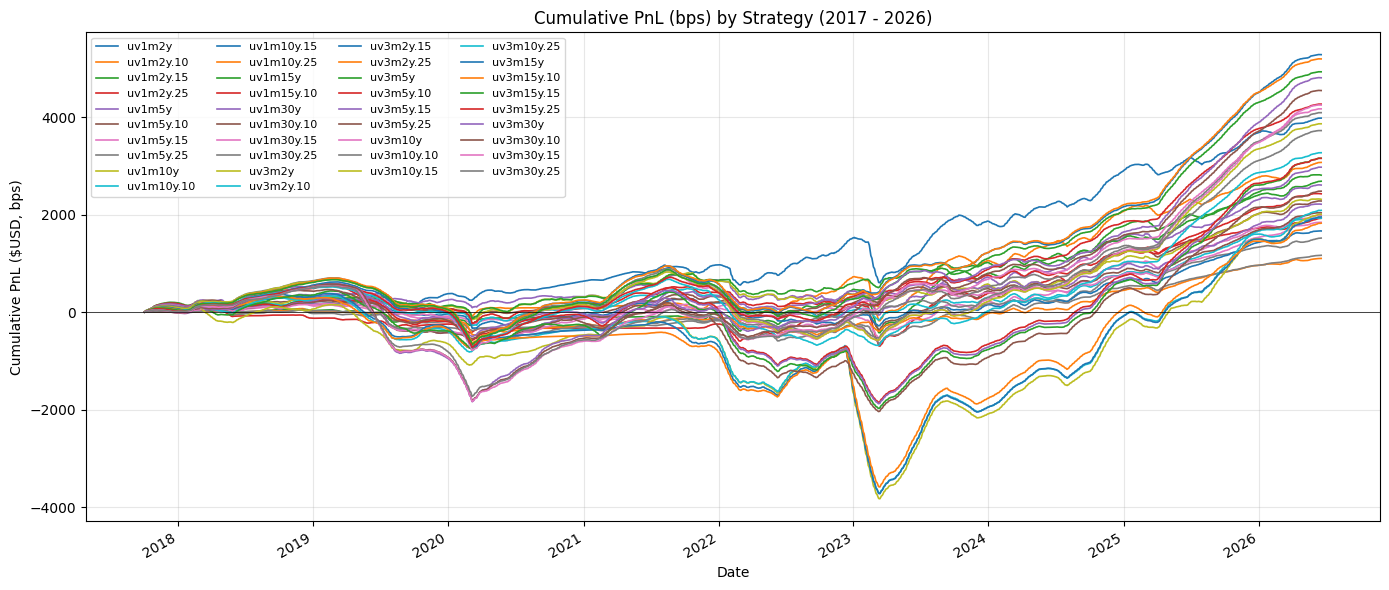

In [639]:
# cumulative PnL across full timeframe

fig, ax = plt.subplots(figsize=(14, 6))
pnl_df.cumsum().plot(ax=ax, lw=1.2)
ax.set_title('Cumulative PnL (bps) by Strategy (2017 - 2026)')
ax.set_ylabel('Cumulative PnL ($USD, bps)')
ax.set_xlabel('Date')
ax.axhline(0, color='black', lw=0.5)
ax.legend(loc = "upper left", fontsize=8, ncol=4)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Most strategies appear to follow a similar trajectory over these years. However, we can immediately notice a difference between certain strategies during large drawdown periods in the beginning of 2020 (COVID-19), and beginning of 2023 (Russia-Ukraine war). Certain strategies remain quite firm, seeing minimal drawdown, while other strategies perform noticeably worse. We can isolate these two instances and tabulate the results.

In [644]:
covid_ss = pnl_df.cumsum().loc[datetime(2020, 3, 20)].sort_values(ascending = False).round(3)
covid_ss.name = "COVID-19 Ordered Cumulative PnL Snapshot"
covid_ss

uv1m2y         344.369
uv1m5y         123.670
uv1m2y.10       27.232
uv1m15y        -59.980
uv1m5y.10      -76.872
uv1m10y       -115.011
uv1m2y.15     -161.403
uv1m15y.10    -170.883
uv1m5y.15     -215.708
uv1m10y.10    -242.348
uv1m10y.15    -306.416
uv1m5y.25     -342.386
uv1m2y.25     -342.405
uv3m5y.15     -430.017
uv1m10y.25    -451.224
uv3m5y.25     -483.968
uv3m5y.10     -503.337
uv3m15y.10    -560.434
uv3m15y.15    -572.304
uv3m10y.10    -573.914
uv3m10y.15    -574.354
uv3m2y.15     -616.147
uv3m2y.25     -616.254
uv3m15y.25    -623.375
uv1m30y.25    -625.563
uv3m10y.25    -635.317
uv1m30y       -649.221
uv1m30y.15    -653.238
uv3m15y       -656.042
uv1m30y.10    -670.920
uv3m2y.10     -689.625
uv3m5y        -694.851
uv3m10y       -709.808
uv3m2y        -949.169
uv3m30y.25   -1601.456
uv3m30y.10   -1706.221
uv3m30y      -1718.417
uv3m30y.15   -1719.366
Name: COVID-19 Ordered Cumulative PnL Snapshot, dtype: float64

In [645]:
russ_uk_ss = pnl_df.cumsum().loc[datetime(2023, 3, 2)].sort_values(ascending = False).round(3)
russ_uk_ss.name = "Russia-Ukraine War Ordered Cumulative PnL Snapshot"
russ_uk_ss

uv1m2y         787.924
uv1m15y        526.124
uv3m15y        390.801
uv3m15y.10     364.770
uv3m30y        289.787
uv1m30y        276.284
uv1m15y.10     275.864
uv3m15y.15     258.268
uv1m30y.10     207.321
uv1m30y.15     162.968
uv3m30y.10     153.035
uv1m10y        149.414
uv3m15y.25     134.835
uv3m30y.15      52.658
uv1m5y          26.941
uv1m30y.25       9.089
uv1m2y.10        5.085
uv3m30y.25     -37.675
uv1m10y.10    -116.265
uv1m10y.15    -237.811
uv1m2y.15     -240.235
uv1m5y.10     -275.316
uv1m10y.25    -351.798
uv1m5y.15     -455.006
uv1m2y.25     -511.682
uv3m10y.10    -519.011
uv1m5y.25     -556.014
uv3m10y.15    -566.682
uv3m10y       -568.348
uv3m10y.25    -677.457
uv3m5y.10    -1799.618
uv3m5y.15    -1829.003
uv3m5y       -1925.045
uv3m5y.25    -1992.102
uv3m2y.25    -3445.102
uv3m2y.10    -3573.803
uv3m2y.15    -3583.602
uv3m2y       -3684.734
Name: Russia-Ukraine War Ordered Cumulative PnL Snapshot, dtype: float64

In [650]:
# final cumulative results by June 2026

final_cum_pnl = pnl_df.cumsum().iloc[-1].sort_values(ascending=False).round(3)
cumulative_pnl = final_cum_pnl.to_frame('cumulative_pnl').reset_index().rename(columns={'index': 'Strategy', 'cumulative_pnl': 'Cumulative PnL by June 2026'})
cumulative_pnl.index = range(1, len(cumulative_pnl) + 1)
cumulative_pnl.index.name = 'Rank'
cumulative_pnl

,Strategy,Cumulative PnL by June 2026
Rank,,
1,uv3m15y,5281.576
2,uv3m15y.10,5193.924
3,uv3m15y.15,4929.509
4,uv3m30y,4806.792
5,uv3m30y.10,4545.426
6,uv3m15y.25,4267.287
7,uv3m30y.15,4248.347
8,uv3m10y,4169.950
9,uv3m10y.10,4091.339


Strategies in the 3m2y family (straddle and strangles) and the 3m5y family consistently perform the worst out of all strategies analyzed during these periods, experiencing notably large drawdowns. These strategies also spend significant time in negative cumulative PnL territory. We can initially weed out these strategies given this visual performance.

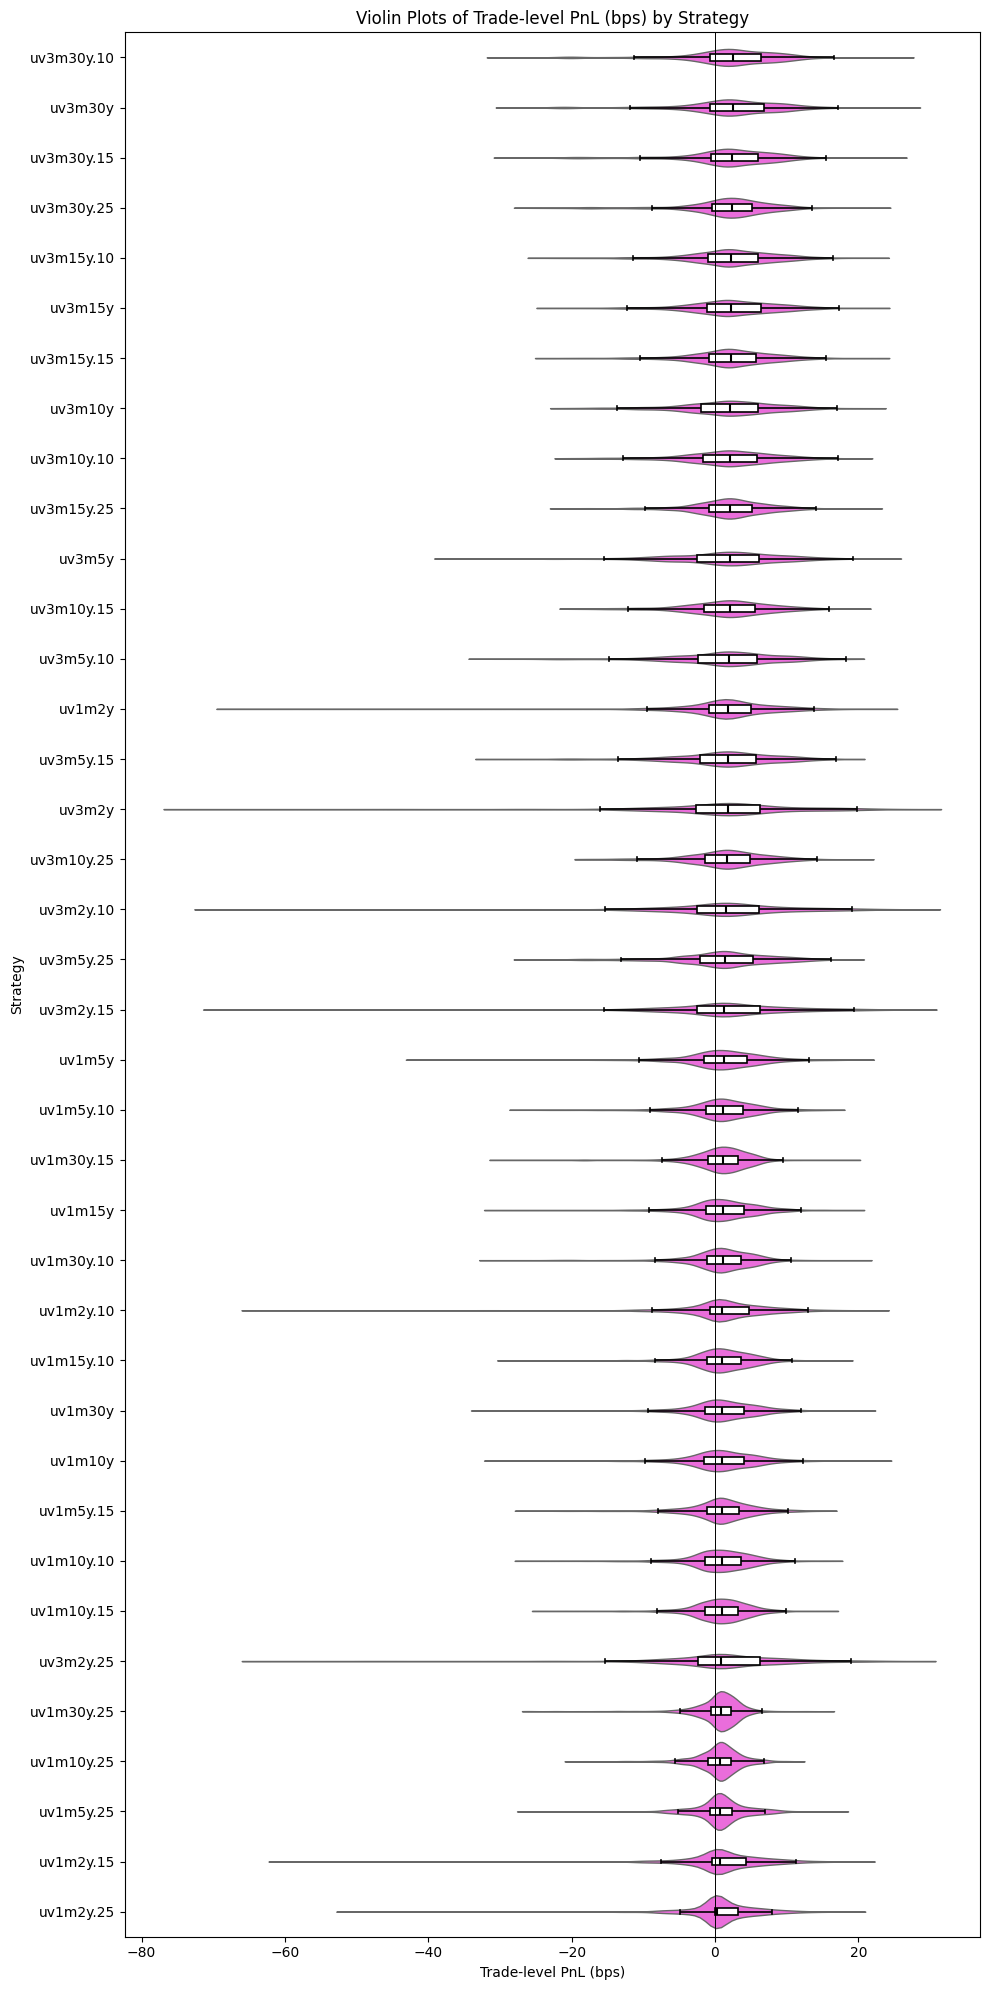

In [666]:
plt.figure(figsize=(10, 20))

ax = sns.violinplot(
    data=pnl_long,
    y="strategy",
    x="daily_pnl",
    order=strategy_order,
    color="#FF58EB",      # light purple
    inner=None,
    cut=0,
    linewidth=1
)

# Overlay boxplot
sns.boxplot(
    data=pnl_long,
    y="strategy",
    x="daily_pnl",
    order=strategy_order,
    width=0.15,
    showcaps=True,
    boxprops={
        "facecolor": "white",
        "edgecolor": "black",
        "linewidth": 1.2
    },
    whiskerprops={
        "color": "black",
        "linewidth": 1.2
    },
    capprops={
        "color": "black",
        "linewidth": 1.2
    },
    medianprops={
        "color": "black",
        "linewidth": 1.5
    },
    flierprops={
        "marker": "",
    }
)

plt.axvline(0, color="black", lw=0.7)
plt.title("Violin Plots of Trade-level PnL (bps) by Strategy")
plt.xlabel("Trade-level PnL (bps)")
plt.ylabel("Strategy")
plt.tight_layout()
plt.show()

The above violin plot shows the full distributions of trade-level PnL per strategy across the full timeline. The ideal strategy shows a high center (median), high upper PnL range, low lower PnL range, and a small total spread. Strategies such as 3m2y are not ideal despite their above-average median, given the long left tail of the strategy distribution. 1m30y 25ew strangle is optimal for its short total range. We are looking for a balance between these characteristics (evidently, the larger the upper tail, the larger the lower tail as well).

In [665]:
# full PnL description, sorted by mean. Can replace with std, min, etc. to get various sorted views.

pnl_full_descrip = pnl_df.describe().round(3)
pnl_full_descrip.T.sort_values(by = "mean", ascending = False)

,count,mean,std,min,25%,50%,75%,max
uv3m15y,2261.0,2.336,6.346,-24.919,-1.119,2.275,6.407,24.363
uv3m15y.10,2261.0,2.297,6.064,-26.152,-0.941,2.283,6.066,24.279
uv3m15y.15,2261.0,2.180,5.883,-25.114,-0.768,2.240,5.747,24.335
uv3m30y,2261.0,2.126,7.294,-30.585,-0.715,2.479,6.824,28.632
uv3m30y.10,2261.0,2.010,6.972,-31.844,-0.673,2.498,6.485,27.726
uv3m15y.25,2261.0,1.887,5.401,-23.036,-0.810,2.104,5.155,23.313
uv3m30y.15,2261.0,1.879,6.730,-30.875,-0.521,2.380,6.075,26.754
uv3m10y,2261.0,1.844,6.622,-23.002,-1.905,2.162,6.041,23.836
uv3m10y.10,2261.0,1.810,6.315,-22.396,-1.631,2.129,5.886,21.963
uv1m2y,2261.0,1.760,7.157,-69.583,-0.759,1.877,5.084,25.446


Overall, we can see that these short gamma strategies struggled to perform meaningfully in the first few years of analysis. However, years 2024 and beyond saw a material pickup in risk-adjusted return.

Certain strategies perform poorly, specifically 3m2y and 3m5y-related strategies. Otherwise, the performance of the other strategies appear to behave similarly across time. Now, we will aim to distinguish between each strategy and evaluate its more granular characteristics.



## Strategy Metrics

To compare the performance between each strategy, we will assign a composite score to each strategy based on metrics such as mean, std, 95% VaR, maximum drawdown, downside standard deviation, etc. Given these are short gamma strategies, more weight will be placed on metrics measuring downside risk. 

We will adopt a bootstrapping approach in order to compare these metrics against each other. This full suite of metrics should adequately cover all return and risk measures we are concerned about, and were derived and chosen based on existing research.

In [688]:
def max_drawdown_val(x):
    cumsum = x.cumsum()
    running_max = cumsum.cummax()
    drawdown = cumsum - running_max
    return drawdown.min()

def downside_std(x):
    neg = x[x < 0]
    return neg.std() if len(neg) > 1 else np.nan

def sortino(x):
    series_mean = x.mean()
    downside = np.minimum(x, 0)
    std_neg = np.sqrt((downside ** 2).mean())
    return (series_mean / std_neg) * np.sqrt(252)

def calmar(x):
    cumulative = x.cumsum()
    mdd = (cumulative - cumulative.cummax()).min()
    return x.mean() * 252 / abs(mdd)

def tail_ratio(x, pct = 0.05):
    upper_p = np.percentile(x, 100 * (1 - pct))
    lower_p = np.percentile(x, 100 * pct)
    return upper_p / lower_p

def cvar(x, pct = 0.05):
    var = np.percentile(x, 100 * pct)
    return x[x <= var].mean()

def cvar_sharpe(x, pct = 0.05):
    c = cvar(x, pct)
    return x.mean() * np.sqrt(252) / abs(c)

weights = pd.Series({
    'mean': 0.5, # want HIGH
    'std': -0.3, # want LOW, so negative
    'var_95': 0.5, # want HIGH
    'sortino': 1.0, # want HIGH
    'calmar': 0.8, # want HIGH
    'tail_ratio': 0.3, # want HIGH
    'cvar': 0.3, # want HIGH
    'cvar_sharpe': 0.8, # want HIGH
    'max_drawdown_val': 0.6, # want HIGH
    'downside_std': -0.5, # want LOW (downside variability)
    'avg_prem': 0.8 # want HIGH
})

def composite_score(strategy_pnl_df, premium_df):
    ranking = pd.DataFrame({
        'mean': strategy_pnl_df.mean(),
        'std': strategy_pnl_df.std(),
        'var_95': strategy_pnl_df.quantile(0.05),
        'sortino': strategy_pnl_df.apply(sortino),
        'calmar': strategy_pnl_df.apply(calmar),
        'tail_ratio': strategy_pnl_df.apply(tail_ratio),
        'cvar': strategy_pnl_df.apply(cvar),
        'cvar_sharpe': strategy_pnl_df.apply(cvar_sharpe),
        'max_drawdown_val': strategy_pnl_df.apply(max_drawdown_val),
        'downside_std': strategy_pnl_df.apply(downside_std),
        'avg_prem': prem_df.mean()
    })

    ranking.index.name = 'Strategy'
    z = (ranking - ranking.mean()) / ranking.std() # everything's gotta be scaled the same

    ranking['composite'] = (z * weights).sum(axis=1) # sum weighted metrics
    ranking = ranking.sort_values('composite', ascending=False)
    return ranking

## Composite Scoring Visualizations

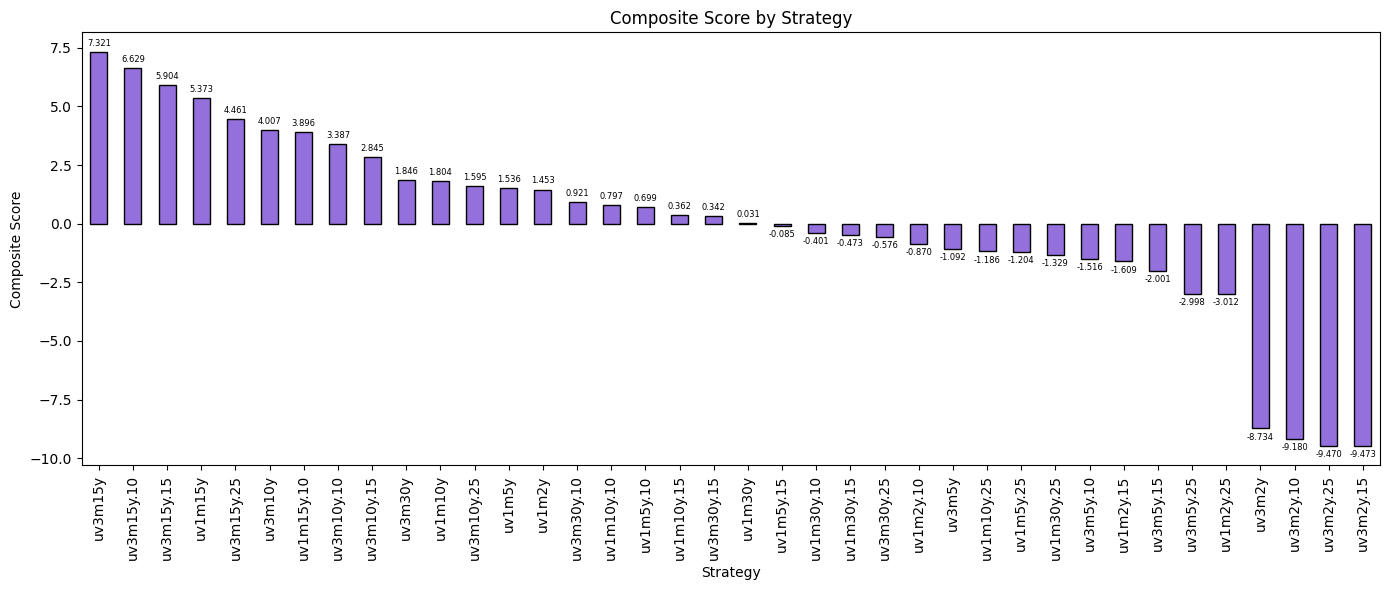

In [689]:
# scoring on full dataset

score_df = composite_score(pnl_df, prem_df)
fig, ax = plt.subplots(figsize=(14, 6))

composite_bar = score_df['composite'].plot(kind='bar',
                                                 ax=ax,
                                                 color='mediumpurple',
                                                 edgecolor='black')

ax.bar_label(ax.containers[0],
             fmt="%.3f",
             fontsize=6,
             padding=3)
ax.set_title('Composite Score by Strategy')
ax.set_xlabel('Strategy')
ax.set_ylabel('Composite Score')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

C:\Users\s1799275\AppData\Roaming\Python\Python311\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\s1799275\AppData\Roaming\Python\Python311\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\s1799275\AppData\Roaming\Python\Python311\site-packages\numpy\_core\fromnumeric.py:54: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)
c:\Users\s1799275\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


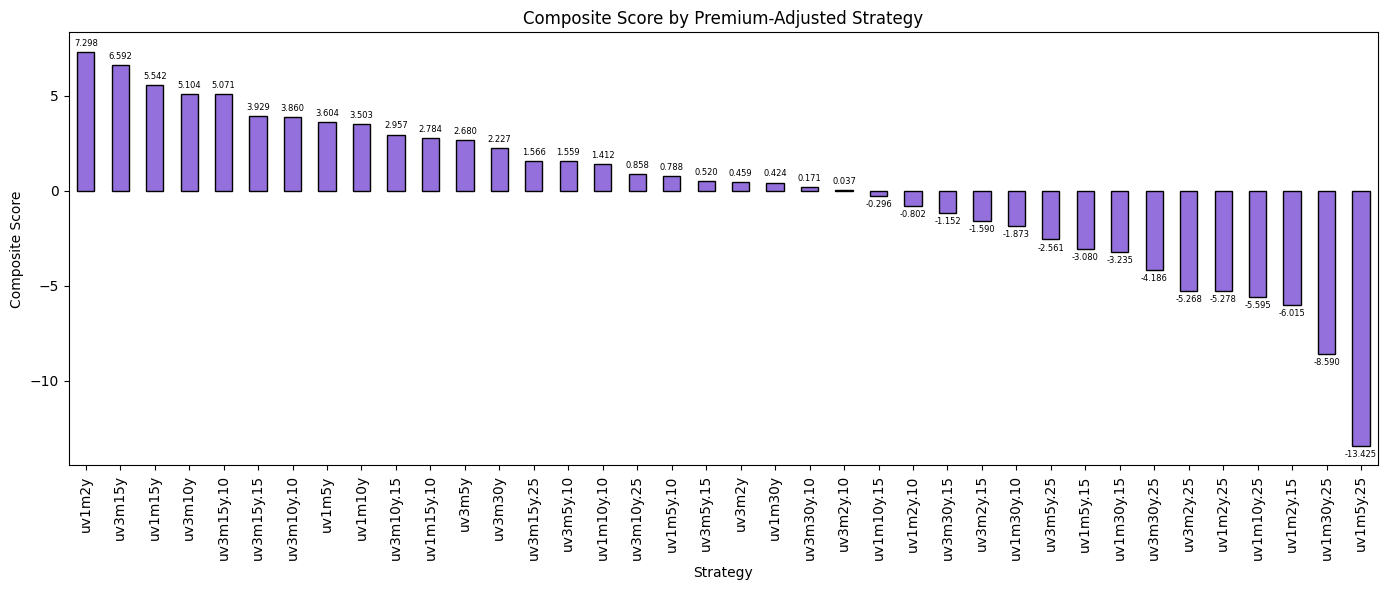

In [690]:
# premium adjusted PnL

prem_adj_pnl = pnl_df / prem_df
prem_adj_pnl = prem_adj_pnl.fillna(0)

score_df_prem_adj = composite_score(prem_adj_pnl, prem_df)
fig, ax = plt.subplots(figsize=(14, 6))

composite_bar_adj = score_df_prem_adj['composite'].plot(kind='bar',
                                                          ax=ax,
                                                          color='mediumpurple',
                                                          edgecolor='black')

ax.bar_label(ax.containers[0],
             fmt="%.3f",
             fontsize=6,
             padding=3)
ax.set_title('Composite Score by Premium-Adjusted Strategy')
ax.set_xlabel('Strategy')
ax.set_ylabel('Composite Score')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Several findings of this scoring practice is consistent from what we've seen in our exploratory analysis.

- The 3m15y and 3m30y strategy families tend to see the most robust performance out of all other strategies. Overall, upper right appears to produce strong results.
- On a premium-adjusted PnL basis, evidently, straddles see the best performance, while 15ew and 25ew strangles perform poorer.

We can plot out these full results in various ways.

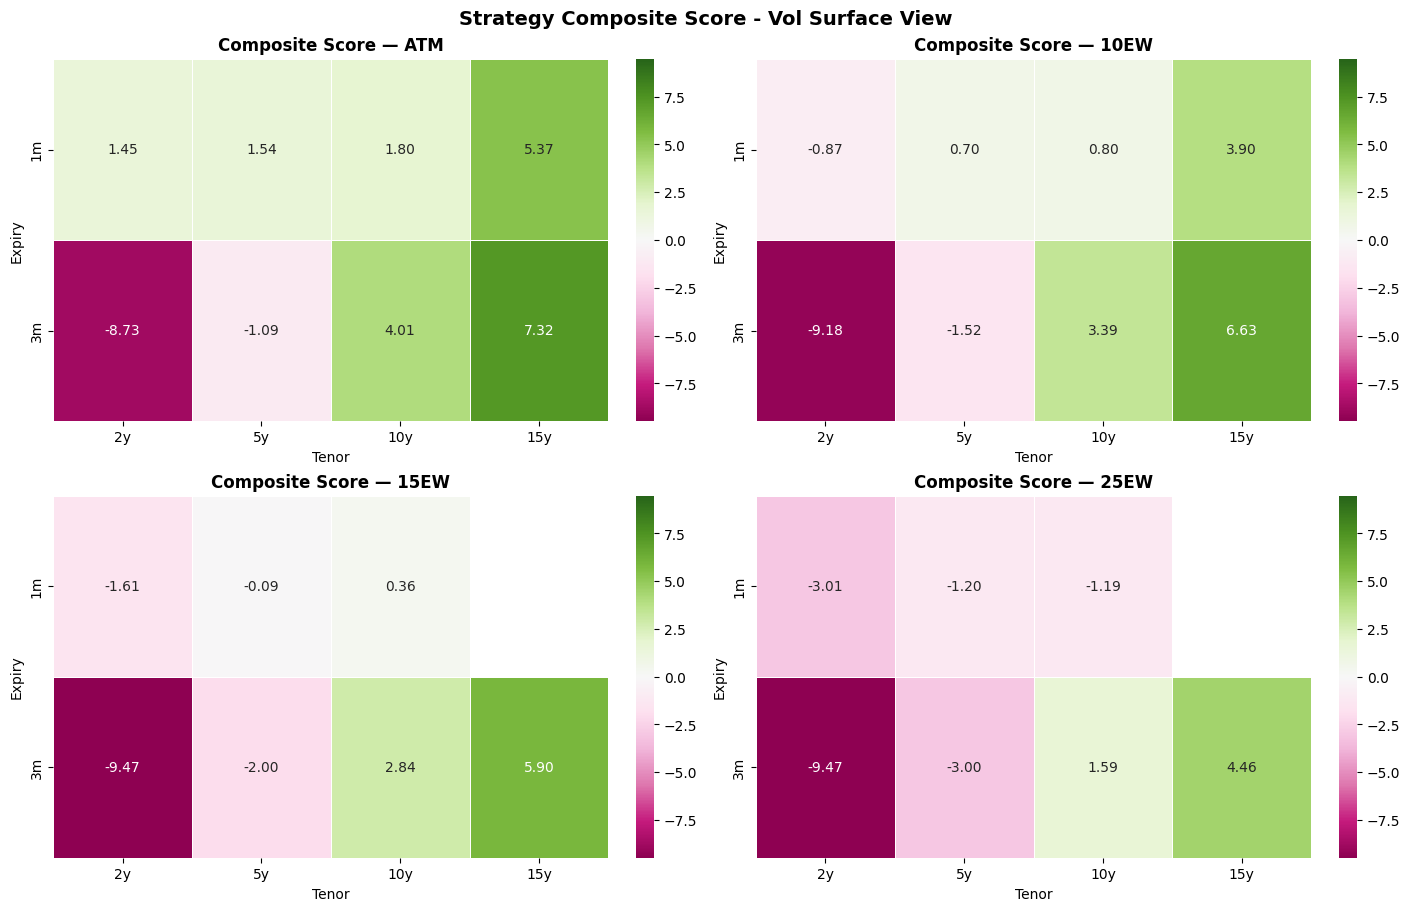

In [692]:
# Heatmap of composite scores on a volatility surface-like view

df = score_df.copy().reset_index()
df = df.rename(columns={df.columns[0]: 'strategy'})   # ensures the index column is named 'strategy'

# ---- 1. Parse the ticker ----
pattern = re.compile(r'uv(\d+m)(\d+y)(?:\.(\d+))?$')

def parse_ticker(s):
    m = pattern.match(s)
    if not m:
        return pd.Series([None, None, None])
    expiry, tenor, skew = m.groups()
    skew_label = f'{skew}ew' if skew else 'atm'
    return pd.Series([expiry, tenor, skew_label])

df[['expiry', 'tenor', 'skew']] = df['strategy'].apply(parse_ticker)

# ---- 2. Set categorical ordering ----
expiry_order = ['1m', '3m']
tenor_order  = ['2y', '5y', '10y', '15y']
skew_order   = ['atm', '10ew', '15ew', '25ew']

df['expiry'] = pd.Categorical(df['expiry'], categories=expiry_order, ordered=True)
df['tenor']  = pd.Categorical(df['tenor'],  categories=tenor_order,  ordered=True)
df['skew']   = pd.Categorical(df['skew'],   categories=skew_order,   ordered=True)

# ---- 3. Build 2x2 grid of heatmaps ----
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

vmin, vmax = df['composite'].min(), df['composite'].max()
abs_max = max(abs(vmin), abs(vmax))

for ax, sk in zip(axes.flat, skew_order):
    sub = df[df['skew'] == sk]
    pivot = sub.pivot(index='expiry', columns='tenor', values='composite')
    pivot = pivot.reindex(index=expiry_order, columns=tenor_order)

    sns.heatmap(
        pivot,
        annot=True, fmt='.2f',
        cmap='PiYG',
        center=0,
        vmin=-abs_max, vmax=abs_max,
        cbar=True,
        linewidths=0.5, linecolor='white',
        ax=ax,
    )
    ax.set_title(f'Composite Score — {sk.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tenor')
    ax.set_ylabel('Expiry')

fig.suptitle('Strategy Composite Score - Vol Surface View', fontsize=14, fontweight='bold')
plt.show()

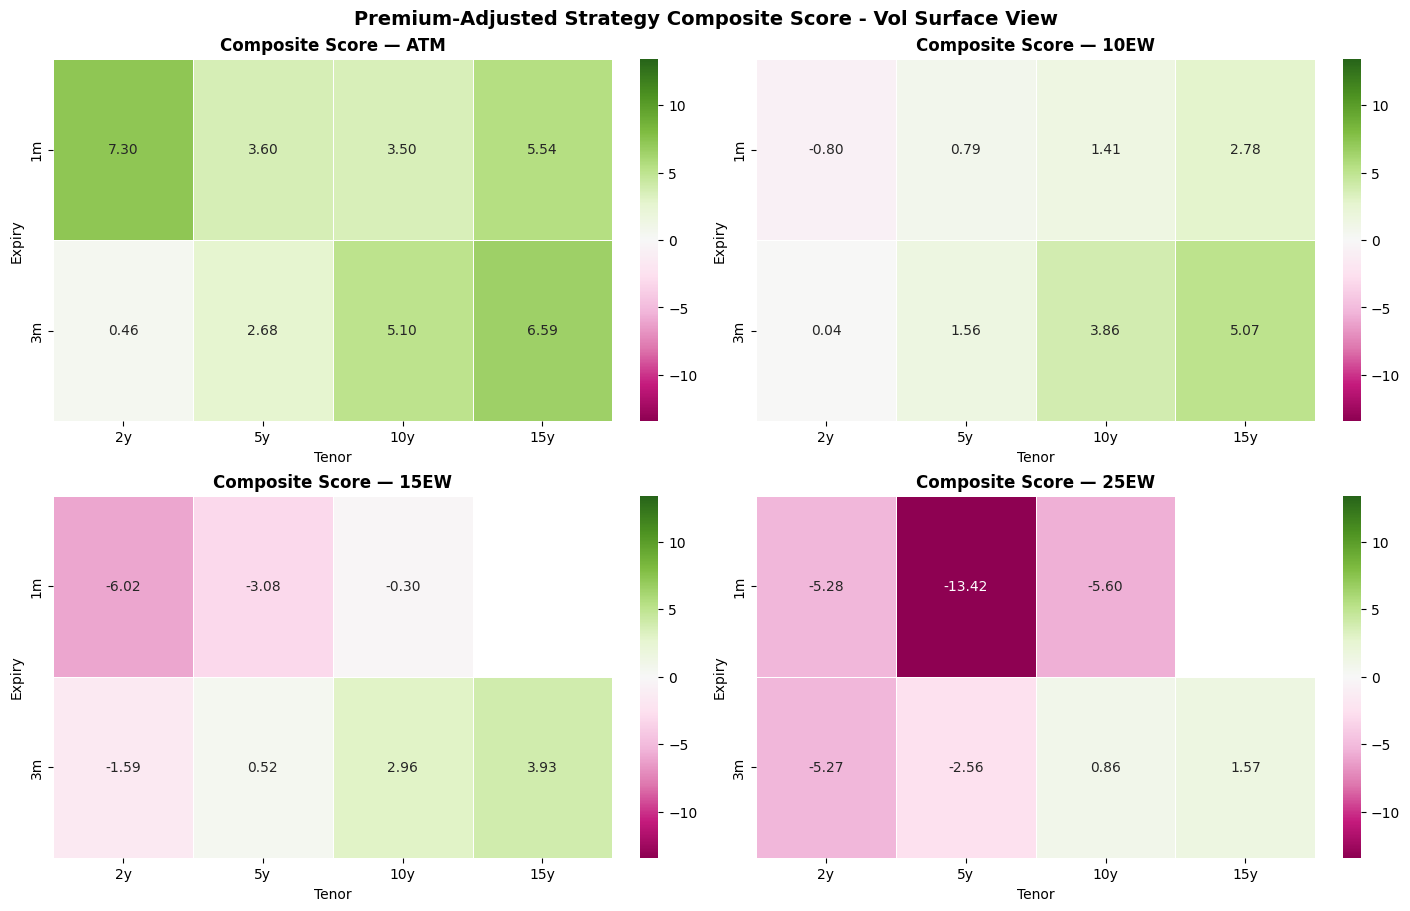

In [700]:
# Prem-adjusted PnL Heatmap of composite scores on a volatility surface-like view

df = score_df_prem_adj.copy().reset_index()
df = df.rename(columns={df.columns[0]: 'strategy'})   # ensures the index column is named 'strategy'

# ---- 1. Parse the ticker ----
pattern = re.compile(r'uv(\d+m)(\d+y)(?:\.(\d+))?$')

def parse_ticker(s):
    m = pattern.match(s)
    if not m:
        return pd.Series([None, None, None])
    expiry, tenor, skew = m.groups()
    skew_label = f'{skew}ew' if skew else 'atm'
    return pd.Series([expiry, tenor, skew_label])

df[['expiry', 'tenor', 'skew']] = df['strategy'].apply(parse_ticker)

# ---- 2. Set categorical ordering ----
expiry_order = ['1m', '3m']
tenor_order  = ['2y', '5y', '10y', '15y']
skew_order   = ['atm', '10ew', '15ew', '25ew']

df['expiry'] = pd.Categorical(df['expiry'], categories=expiry_order, ordered=True)
df['tenor']  = pd.Categorical(df['tenor'],  categories=tenor_order,  ordered=True)
df['skew']   = pd.Categorical(df['skew'],   categories=skew_order,   ordered=True)

# ---- 3. Build 2x2 grid of heatmaps ----
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

vmin, vmax = df['composite'].min(), df['composite'].max()
abs_max = max(abs(vmin), abs(vmax))

for ax, sk in zip(axes.flat, skew_order):
    sub = df[df['skew'] == sk]
    pivot = sub.pivot(index='expiry', columns='tenor', values='composite')
    pivot = pivot.reindex(index=expiry_order, columns=tenor_order)

    sns.heatmap(
        pivot,
        annot=True, fmt='.2f',
        cmap='PiYG',
        center=0,
        vmin=-abs_max, vmax=abs_max,
        cbar=True,
        linewidths=0.5, linecolor='white',
        ax=ax,
    )
    ax.set_title(f'Composite Score — {sk.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tenor')
    ax.set_ylabel('Expiry')

fig.suptitle('Premium-Adjusted Strategy Composite Score - Vol Surface View', fontsize=14, fontweight='bold')
plt.show()

Isolating to certain scaled ratios:

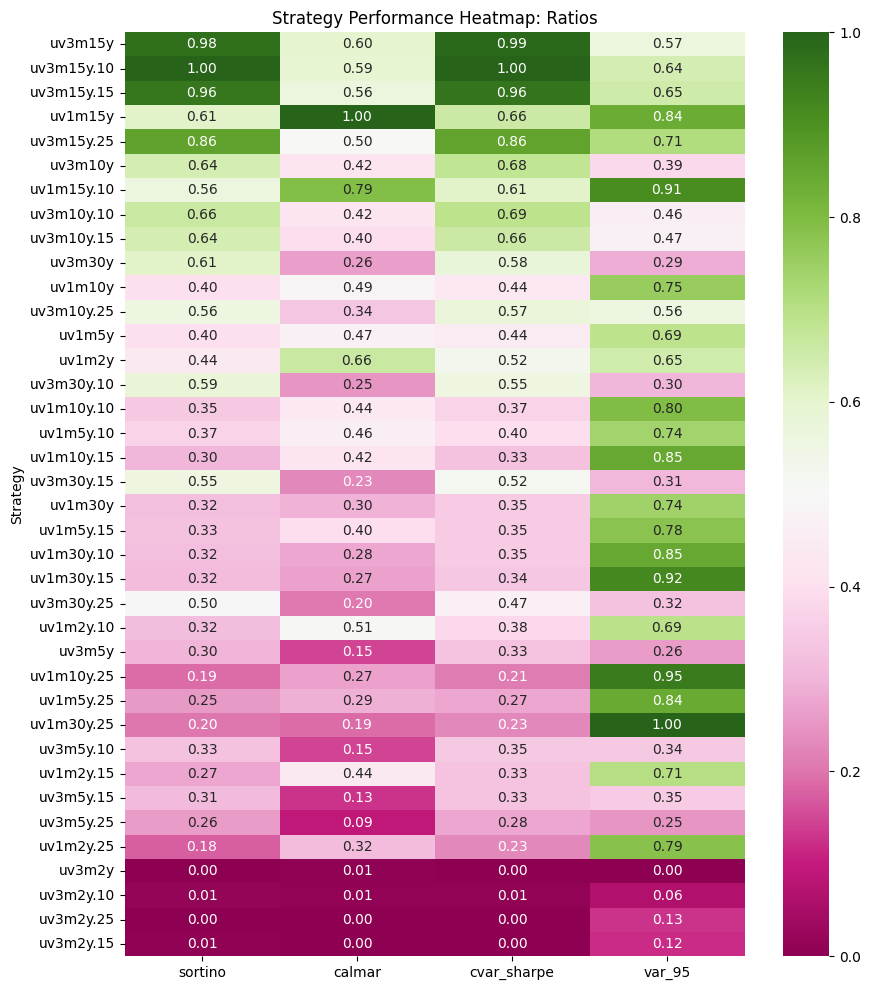

In [702]:
plt.figure(figsize=(10, 12))
heat_df = score_df[['sortino', 'calmar', 'cvar_sharpe', 'var_95']]
heat_df = ((heat_df - heat_df.min()) / (heat_df.max() - heat_df.min())) # normalization

sns.heatmap(heat_df,
            cmap='PiYG',
            annot=True,
            fmt=".2f")

plt.title("Strategy Performance Heatmap: Ratios")
plt.show()

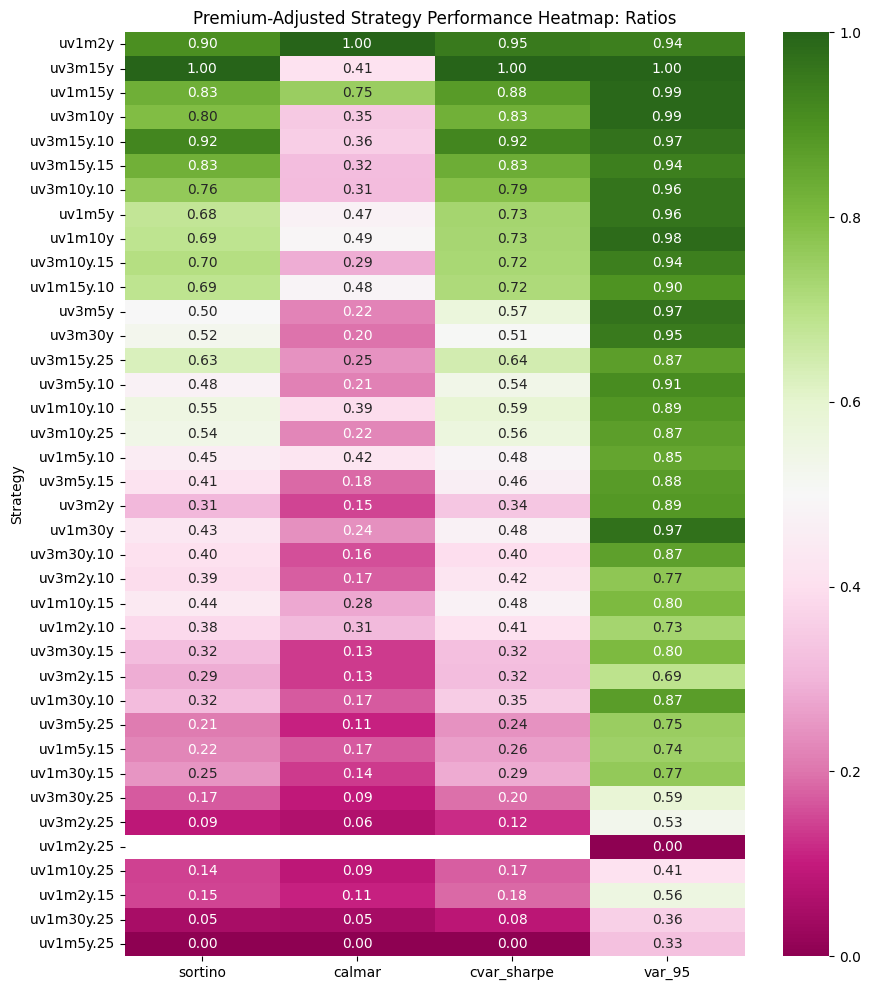

In [703]:
plt.figure(figsize=(10, 12))
heat_df = score_df_prem_adj[['sortino', 'calmar', 'cvar_sharpe', 'var_95']]
heat_df = ((heat_df - heat_df.min()) / (heat_df.max() - heat_df.min())) # normalization

sns.heatmap(heat_df,
            cmap='PiYG',
            annot=True,
            fmt=".2f")

plt.title("Premium-Adjusted Strategy Performance Heatmap: Ratios")
plt.show()

Once again, these results are consistent with our previous hypotheses. 3m15y and 3m10y are top performers, and tighter widths seem to perform better even when adjusting for premium received. To verify these results, we conduct a block bootstrapping analysis to assess if timeframes were randomized, do we tend to see the same top-performing strategies appear?

## Block Bootstrap of Scores

We evaluate strategy robustness using a moving block bootstrap. Historical data is repeatedly resampled by randomly selecting and concatenating blocks of consecutive observations, preserving the time series structure of the original data. For each resampled history, we recalculate strategy metrics and the composite score. Repeating this process 1,000 times generates a distribution of outcomes, allowing us to identify strategies that consistently perform well across many plausible market scenarios rather than relying on a single historical path. 

We construct a 50-observation bootstrap sample by randomly selecting blocks of 45 consecutive days from the original history. We then repeat this full process 1000x and collect scores and all statistics.

In [749]:
strat_cols = list(pnl_df.columns)

def moving_block_bootstrap(df, sample_length, block_length, seed=None):
    rng = np.random.default_rng(seed)
    T = len(df)
    
    if block_length >= T:
        raise ValueError("Block length must be smaller than dataframe length")
    
    n_blocks = int(np.ceil(sample_length / block_length))
    max_start = T - block_length
    starts = rng.integers(0, max_start + 1, size=n_blocks)

    pieces = []
    for s in starts:
        block = df.iloc[s:s + block_length].copy()
        block['original_date'] = df.index[s:s + block_length]
        block['block_id']      = s
        pieces.append(block)
    
    sample = pd.concat(pieces, ignore_index=True)
    sample = sample.iloc[:sample_length].reset_index(drop=True)
    
    sample.insert(0, 'boot_day', range(1, len(sample) + 1))
    
    return sample

bootstrap_instances = 50

bootstrapped_scores = []
bootstrapped_mean = []
bootstrapped_std = []
bootstrapped_var_95 = []
bootstrapped_sortino = []
bootstrapped_calmar = []
bootstrapped_tail_ratio = []
bootstrapped_cvar = []
bootstrapped_cvar_sharpe = []
bootstrapped_mdd = []
bootstrapped_downside_std = []
bootstrapped_avg_prem = []

with warnings.catch_warnings(): # some div by zero
    warnings.simplefilter("ignore", RuntimeWarning)

    for b in range(bootstrap_instances):
        rng = np.random.randint(1000)
        boot = moving_block_bootstrap(pnl_df, sample_length=50, block_length=45, seed = rng)

        bootstrapped_pnl = boot[strat_cols]
        bootstrapped_prem = prem_df.loc[boot['original_date']].reset_index(drop = True)

        bootstrapped_scoring = composite_score(bootstrapped_pnl, bootstrapped_prem)

        bootstrapped_scores.append(bootstrapped_scoring['composite'].to_frame(name=b).T)
        bootstrapped_mean.append(bootstrapped_scoring['mean'].to_frame(name=b).T)
        bootstrapped_std.append(bootstrapped_scoring['std'].to_frame(name=b).T)
        bootstrapped_var_95.append(bootstrapped_scoring['var_95'].to_frame(name=b).T)
        bootstrapped_sortino.append(bootstrapped_scoring['sortino'].to_frame(name=b).T)
        bootstrapped_calmar.append(bootstrapped_scoring['calmar'].to_frame(name=b).T)
        bootstrapped_tail_ratio.append(bootstrapped_scoring['tail_ratio'].to_frame(name=b).T)
        bootstrapped_cvar.append(bootstrapped_scoring['cvar'].to_frame(name=b).T)
        bootstrapped_cvar_sharpe.append(bootstrapped_scoring['cvar_sharpe'].to_frame(name=b).T)
        bootstrapped_mdd.append(bootstrapped_scoring['max_drawdown_val'].to_frame(name=b).T)
        bootstrapped_downside_std.append(bootstrapped_scoring['downside_std'].to_frame(name=b).T)
        bootstrapped_avg_prem.append(bootstrapped_scoring['avg_prem'].to_frame(name=b).T)

## Bootstrap Summary

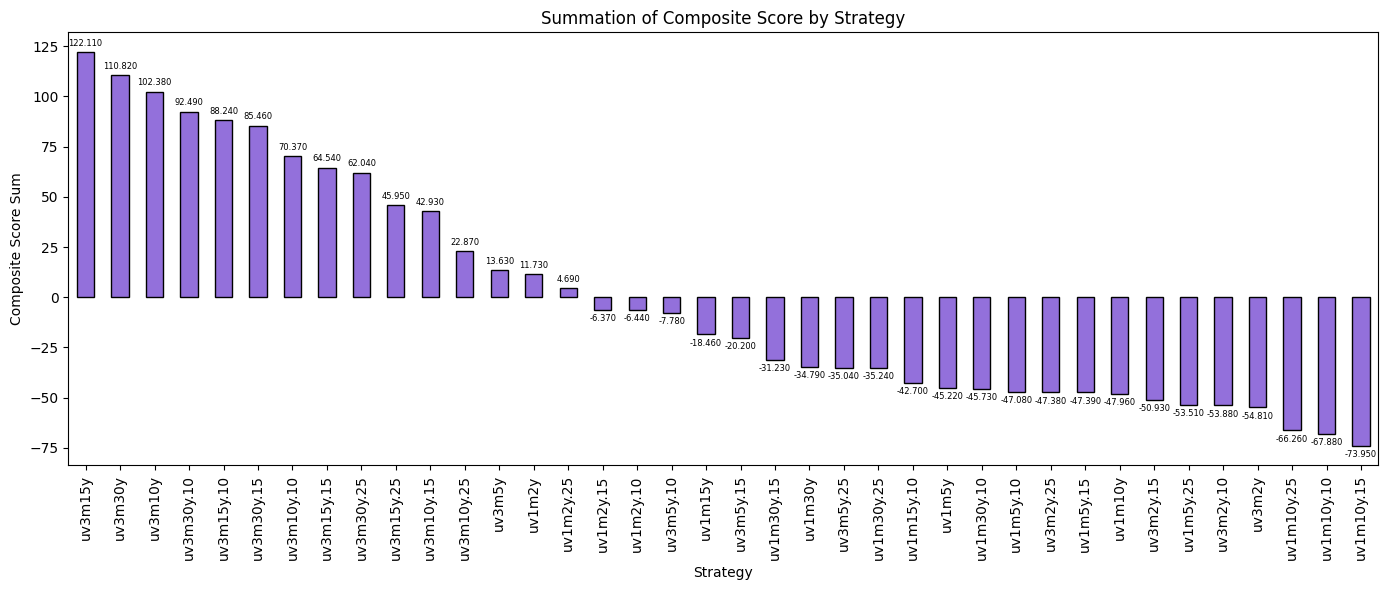

In [750]:
bootstrap_summary = pd.concat(bootstrapped_scores, ignore_index=True).sum().sort_values(ascending = False).round(2).rename("Summation of Bootstrapped Composite Scores")

fig, ax = plt.subplots(figsize=(14, 6))

composite_bar = bootstrap_summary.plot(kind='bar', ax=ax,
                                       color='mediumpurple',
                                       edgecolor='black')

ax.bar_label(ax.containers[0],
             fmt="%.3f",
             fontsize=6,
             padding=3)

ax.set_title('Summation of Composite Score by Strategy')
ax.set_xlabel('Strategy')
ax.set_ylabel('Composite Score Sum')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

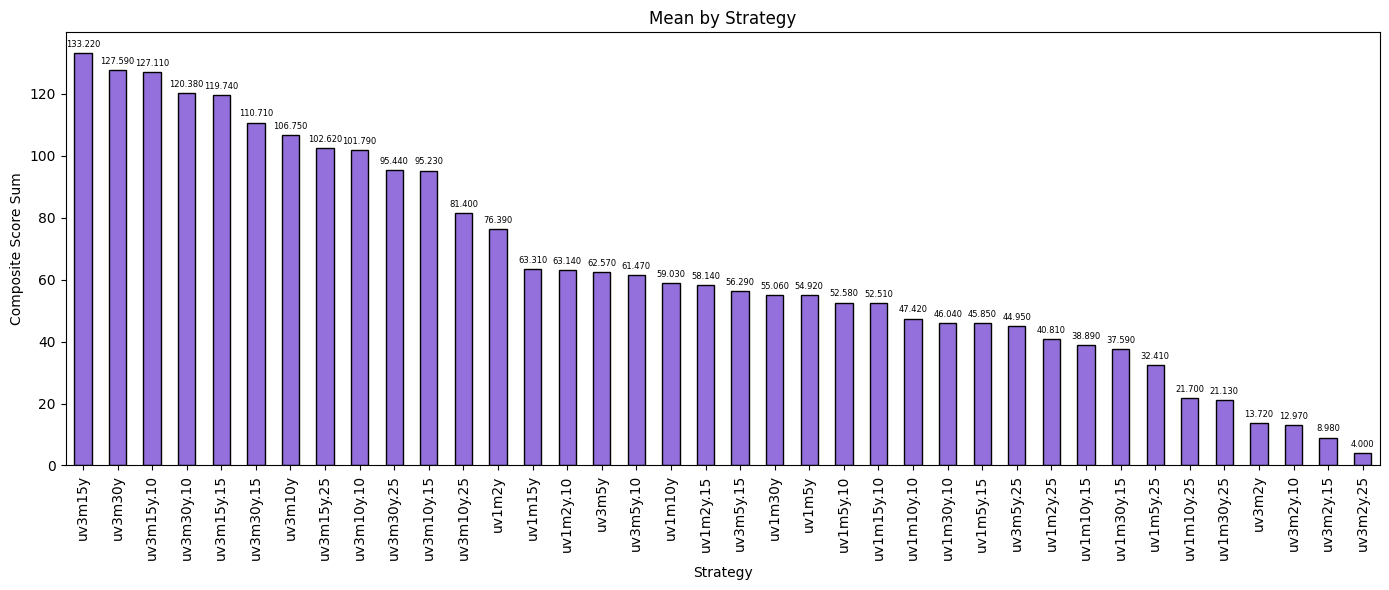

In [751]:
bootstrap_mean = pd.concat(bootstrapped_mean, ignore_index=True).sum().sort_values(ascending = False).round(2).rename("Summation of Bootstrapped Composite Scores")

fig, ax = plt.subplots(figsize=(14, 6))

composite_bar = bootstrap_mean.plot(kind='bar', ax=ax,
                                       color='mediumpurple',
                                       edgecolor='black')

ax.bar_label(ax.containers[0],
             fmt="%.3f",
             fontsize=6,
             padding=3)

ax.set_title('Mean by Strategy')
ax.set_xlabel('Strategy')
ax.set_ylabel('Composite Score Sum')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Can replace the below with any metric to visualize rankings.

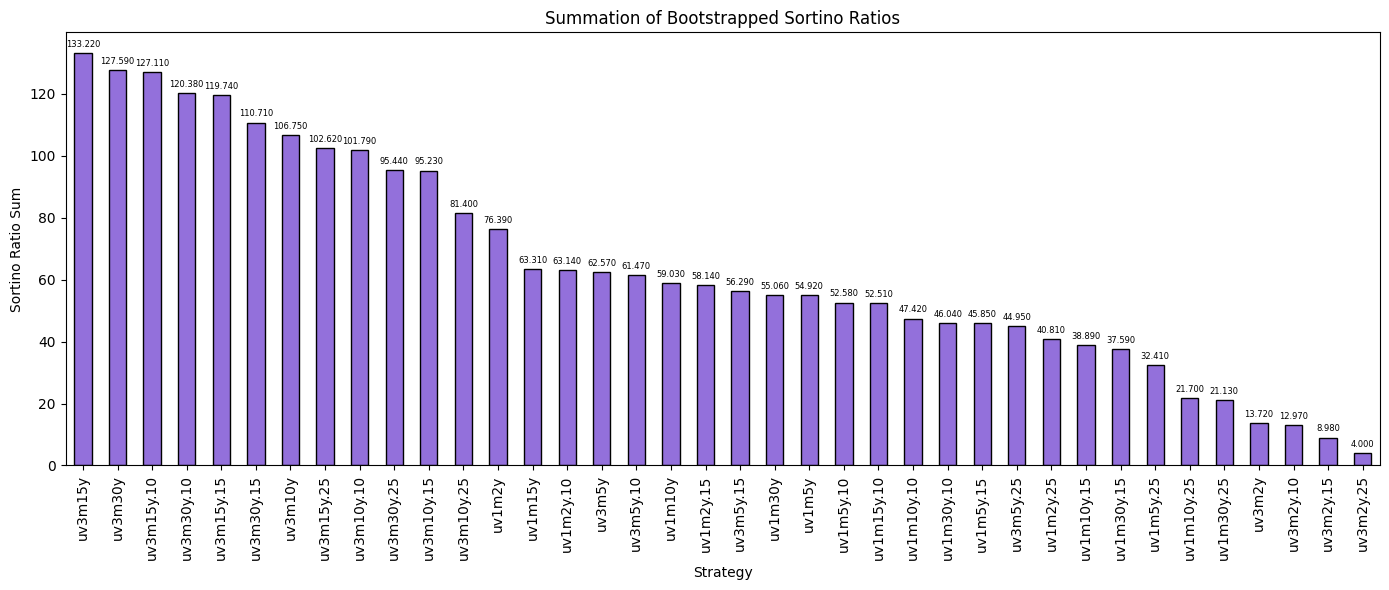

In [752]:
bootstrap_sortino = pd.concat(bootstrapped_sortino, ignore_index=True).sum().sort_values(ascending = False).round(2).rename("Summation of Bootstrapped Sortino Ratios")

fig, ax = plt.subplots(figsize=(14, 6))

composite_bar = bootstrap_mean.plot(kind='bar', ax=ax,
                                       color='mediumpurple',
                                       edgecolor='black')

ax.bar_label(ax.containers[0],
             fmt="%.3f",
             fontsize=6,
             padding=3)

ax.set_title('Summation of Bootstrapped Sortino Ratios')
ax.set_xlabel('Strategy')
ax.set_ylabel('Sortino Ratio Sum')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Overall, 3m15y straddle performs the best in every metric, when considering 50 bootstrap samples or up to 1000. This consistency is notable, and we notice the same pattern for the 3m15y strategy family and 3m30y family. On a bootstrapped basis, these tend to consistently dominate. We can replicate the same analysis on the premiun-adjusted PnL.

In [ ]:
bootstrap_instances = 50

bootstrapped_scores = []
bootstrapped_mean = []
bootstrapped_std = []
bootstrapped_var_95 = []
bootstrapped_sortino = []
bootstrapped_calmar = []
bootstrapped_tail_ratio = []
bootstrapped_cvar = []
bootstrapped_cvar_sharpe = []
bootstrapped_mdd = []
bootstrapped_downside_std = []
bootstrapped_avg_prem = []

with warnings.catch_warnings(): # some div by zero
    warnings.simplefilter("ignore", RuntimeWarning)

    for b in range(bootstrap_instances):
        rng = np.random.randint(1000)
        boot = moving_block_bootstrap(prem_adj_pnl, sample_length=50, block_length=45, seed = rng)

        bootstrapped_pnl = boot[strat_cols]
        bootstrapped_prem = prem_df.loc[boot['original_date']].reset_index(drop = True)

        bootstrapped_scoring = composite_score(bootstrapped_pnl, bootstrapped_prem)

        bootstrapped_scores.append(bootstrapped_scoring['composite'].to_frame(name=b).T)
        bootstrapped_mean.append(bootstrapped_scoring['mean'].to_frame(name=b).T)
        bootstrapped_std.append(bootstrapped_scoring['std'].to_frame(name=b).T)
        bootstrapped_var_95.append(bootstrapped_scoring['var_95'].to_frame(name=b).T)
        bootstrapped_sortino.append(bootstrapped_scoring['sortino'].to_frame(name=b).T)
        bootstrapped_calmar.append(bootstrapped_scoring['calmar'].to_frame(name=b).T)
        bootstrapped_tail_ratio.append(bootstrapped_scoring['tail_ratio'].to_frame(name=b).T)
        bootstrapped_cvar.append(bootstrapped_scoring['cvar'].to_frame(name=b).T)
        bootstrapped_cvar_sharpe.append(bootstrapped_scoring['cvar_sharpe'].to_frame(name=b).T)
        bootstrapped_mdd.append(bootstrapped_scoring['max_drawdown_val'].to_frame(name=b).T)
        bootstrapped_downside_std.append(bootstrapped_scoring['downside_std'].to_frame(name=b).T)
        bootstrapped_avg_prem.append(bootstrapped_scoring['avg_prem'].to_frame(name=b).T)

## Analyzing Top-performing Strategies

- 3m15y, atm, 10ew, 15ew, 25ew
- 1m2y
- 1m15y
- 3m10y, atm and 10 ew

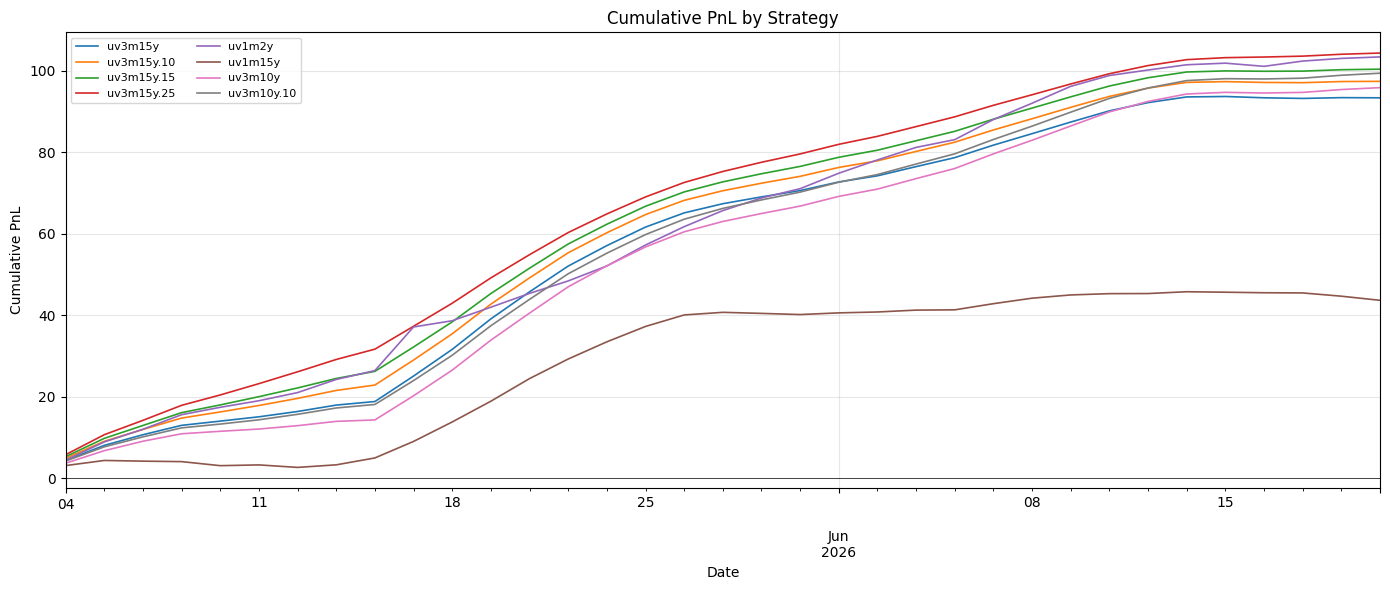

In [560]:
selected_strategies = ['uv3m15y', 'uv3m15y.10', 'uv3m15y.15', 'uv3m15y.25',
                       'uv1m2y', 'uv1m15y', 'uv3m10y', 'uv3m10y.10']

fig, ax = plt.subplots(figsize=(14, 6))
original_pnl_ts[datetime(2026, 5, 2):][selected_strategies].cumsum().plot(ax=ax, lw=1.2)
# original_pnl_ts[datetime(2026, 1, 2):][selected_strategies].plot(ax=ax, lw=1.2)
# original_pnl_ts[selected_strategies].cumsum().plot(ax=ax, lw=1.2)
ax.set_title('Cumulative PnL by Strategy')
ax.set_ylabel('Cumulative PnL')
ax.set_xlabel('Date')
ax.axhline(0, color='black', lw=0.5)
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## See if each strategy differs by each other

In [621]:
# pip install arch
from arch.bootstrap import MCS

losses = -pnl_df.dropna()
mcs = MCS(losses, size=0.05, reps=2000, block_size=21, method='R')
mcs.compute()

print("Strategies in the 95% Model Confidence Set:")
print(mcs.included)
print("\nStrategies excluded (statistically worse than the set):")
print(mcs.excluded)
print("\nMCS p-values:")
print(mcs.pvalues)

np.float64(2.466202012642074e-18)

## Regime Analysis

In [561]:
import re
import pandas as pd
import numpy as np

pnl_df = original_pnl_ts[selected_strategies].copy()

pnl_df['total'] = original_pnl_ts[selected_strategies].sum(axis = 1)
# pnl_df['std'] = pnl_df['total'].rolling(63).std()
# pnl_df['tail_ratio'] = pnl_df['total'].rolling(63).apply(tail_ratio)
# pnl_df['var_95'] = pnl_df['total'].rolling(63).quantile(0.05)
# pnl_df['max_drawdown_val'] = pnl_df['total'].rolling(63).apply(max_drawdown_val)

pnl_df = pnl_df[datetime(2018, 1, 2):]

In [562]:
vars_of_interest = ['uv1m2y', 'uv1m5y', 'uv1m10y', 'uv3m2y', 'uv3m5y', 'uv3m10y',
                    'uv1y2y', 'uv1y5y', 'uv1y10y', 'u2y', 'u5y', 'u10y',
                    'u1m2y', 'u1m5y', 'u1m10y', 'u3m2y', 'u3m5y', 'u3m10y', 'u1y2y', 'u1y5y', 'u1y10y']

variables_query = f"""SELECT date, name, value FROM prod.series_view WHERE name = ANY(ARRAY{vars_of_interest}) and value_name = 'value'
AND date >= '{start_date}' AND date <= '{end_date}'
ORDER BY date ASC;
"""

var_df = db.get(variables_query).reset_index(drop = True)
var_df_pivot = var_df.pivot(index="date", columns="name", values="value")
var_df_pivot

name,u10y,u1m10y,u1m2y,u1m5y,u1y10y,u1y2y,u1y5y,u2y,u3m10y,u3m2y,...,u5y,uv1m10y,uv1m2y,uv1m5y,uv1y10y,uv1y2y,uv1y5y,uv3m10y,uv3m2y,uv3m5y
date,,,,,,,,,,,,,,,,,,,,,
2017-10-02,1.974279,1.985635,1.541470,1.758518,2.077290,1.725597,1.889305,1.515590,2.004598,1.585753,...,1.741784,62.429726,39.711868,57.754489,67.579010,52.549560,65.334620,61.895756,41.496995,57.531447
2017-10-03,1.967329,1.978523,1.540888,1.745801,2.071058,1.712589,1.873296,1.516816,1.998061,1.584286,...,1.729904,62.871785,41.211602,58.294548,67.539047,52.871299,65.309113,61.864635,41.935378,57.518119
2017-10-04,1.967718,1.978553,1.543936,1.748762,2.071154,1.717607,1.878740,1.520382,1.999022,1.588550,...,1.733224,60.613037,40.640452,57.194523,67.538812,52.816434,65.027933,61.848147,41.870852,58.022262
2017-10-05,1.982566,1.993030,1.564209,1.770536,2.084271,1.739815,1.897557,1.539102,2.012748,1.607466,...,1.755041,61.132957,41.511247,58.949261,68.028356,53.254966,65.626308,62.742299,43.535883,59.131351
2017-10-06,1.997455,2.008890,1.582195,1.792087,2.098104,1.760896,1.920050,1.555031,2.027505,1.625812,...,1.774738,60.174267,39.887831,57.655603,67.508069,53.306747,65.378178,61.579236,42.446053,58.002650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-15,4.066975,4.073622,3.931136,3.913887,4.130199,3.925980,3.947929,3.922646,4.086809,3.944910,...,3.908267,65.519640,86.080077,76.440639,77.910722,93.516593,85.729118,69.094033,85.970941,79.042137
2026-06-16,4.019579,4.026255,3.910334,3.875533,4.076734,3.883386,3.897584,3.903066,4.037770,3.919446,...,3.870503,63.240513,81.523009,73.930523,77.077824,91.000098,84.798787,67.709139,82.673137,76.199460
2026-06-17,4.050631,4.056505,4.030473,3.947987,4.091492,3.975518,3.946366,4.020214,4.067046,4.042099,...,3.943215,64.526997,81.451061,74.377119,77.084803,91.132408,84.418177,68.536598,84.566253,78.061356


In [563]:
# add transformations/ratios of core variables
import numpy as np

helper_df = pd.DataFrame()

fwd_rates_list = ['u1m2y', 'u1m5y', 'u1m10y', 
                  'u3m2y', 'u3m5y', 'u3m10y',
                  'u1y2y', 'u1y5y', 'u1y10y']

iv_list = ['uv1m2y', 'uv1m5y', 'uv1m10y', 
           'uv3m2y', 'uv3m5y', 'uv3m10y',
           'uv1y2y', 'uv1y5y', 'uv1y10y']

for col in range(len(fwd_rates_list)):
    realized_vol_21 = var_df_pivot[fwd_rates_list[col]].diff().rolling(window=21).std() * np.sqrt(252) * 100
    helper_df[f"{fwd_rates_list[col]}_rv_1m"] = realized_vol_21
    helper_df[f"{fwd_rates_list[col]}_rv_1m"] = helper_df[f"{fwd_rates_list[col]}_rv_1m"].fillna(0)

    realized_vol_63 = var_df_pivot[fwd_rates_list[col]].diff().rolling(window=63).std() * np.sqrt(252) * 100
    helper_df[f"{fwd_rates_list[col]}_rv_3m"] = realized_vol_63
    helper_df[f"{fwd_rates_list[col]}_rv_3m"] = helper_df[f"{fwd_rates_list[col]}_rv_3m"].fillna(0)

    vvol_21 = var_df_pivot[iv_list[col]].diff().rolling(window=21).std() * np.sqrt(252)
    helper_df[f"{iv_list[col]}_vvol_1m"] = vvol_21

    vvol_63 = var_df_pivot[iv_list[col]].diff().rolling(window=63).std() * np.sqrt(252)
    helper_df[f"{iv_list[col]}_vvol_3m"] = vvol_63

for rate in ['u2y', 'u5y', 'u10y']:
    rolling_mean_1m = var_df_pivot[rate].rolling(window=21).mean()
    rolling_std_1m = var_df_pivot[rate].rolling(window=21).std()
    helper_df[f'{rate}_zscore_1m'] = (var_df_pivot[rate] - rolling_mean_1m) / rolling_std_1m

    rolling_mean_3m = var_df_pivot[rate].rolling(window=63).mean()
    rolling_std_3m = var_df_pivot[rate].rolling(window=63).std()
    helper_df[f'{rate}_zscore_3m'] = (var_df_pivot[rate] - rolling_mean_3m) / rolling_std_3m

helper_df['u2s10s'] = var_df_pivot['u10y'] - var_df_pivot['u2y']
helper_df['uv3ms1ys'] = var_df_pivot['uv1y10y'] - var_df_pivot['uv3m10y']
helper_df['uv3ms2ys'] = var_df_pivot['uv1y2y'] - var_df_pivot['uv3m2y']

# vol risk prem
helper_df['uv1m2y_1m_ratio'] = var_df_pivot['uv1m2y'] / helper_df['u1m2y_rv_1m']
helper_df['uv1m2y_3m_ratio'] = var_df_pivot['uv1m2y'] / helper_df['u1m2y_rv_3m']

helper_df['uv1m5y_1m_ratio'] = var_df_pivot['uv1m5y'] / helper_df['u1m5y_rv_1m']
helper_df['uv1m5y_3m_ratio'] = var_df_pivot['uv1m5y'] / helper_df['u1m5y_rv_3m']

helper_df['uv1m10y_1m_ratio'] = var_df_pivot['uv1m10y'] / helper_df['u1m10y_rv_1m']
helper_df['uv1m10y_3m_ratio'] = var_df_pivot['uv1m10y'] / helper_df['u1m10y_rv_3m']

In [564]:
# var_df_pivot = var_df_pivot[]
from datetime import datetime

df_pivot = df_pivot[datetime(2018, 1, 2).date():]
var_df_pivot = var_df_pivot[datetime(2018, 1, 2).date():]
helper_df = helper_df[datetime(2018, 1, 2).date():]
macro_df = pd.concat([var_df_pivot, helper_df], axis = 1)

pnl_df = pnl_df[datetime(2018, 1, 2).date():]

# full_X = pd.concat([var_df_pivot, helper_df], axis = 1)

## Pre-Processing

In [565]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# X_raw = full_X.copy()
X_raw = pnl_df.copy()
X_scaled = scaler.fit_transform(X_raw.values)

## Hidden Markov Model

In [566]:
from hmmlearn.hmm import GaussianHMM

def fit_hmm(X, n_states, n_iter = 1000, n_init = 10, seed = 42):

    best_model, best_ll = None, -np.inf
    for i in range(n_init):
        model = GaussianHMM(n_components = n_states,
                            covariance_type = "diag",
                            n_iter = n_iter,
                            tol = 1e-4,
                            random_state = seed + i)
        model.fit(X)
        ll = model.score(X) * len(X)
        if ll > best_ll:
            best_ll, best_model = ll, model
    return best_model, best_ll

def bic(log_likelihood, n_params, T):
    return -2 * log_likelihood + n_params * np.log(T)

def n_params_gaussian_hmm(n_states, n_features):
    transition = n_states * (n_states - 1)
    init = n_states - 1
    means = n_states * n_features
    cov = n_states * n_features # diag cov type
    return transition + init + means + cov

In [567]:
T, K = X_scaled.shape
bic_scores, models_by_k = {}, {}

for k in range(2, 7):
    model, ll = fit_hmm(X_scaled, k)
    n_p = n_params_gaussian_hmm(k, K)
    b = bic(ll, n_p, T)
    bic_scores[k] = b
    models_by_k[k] = model

best_k = min(bic_scores, key = bic_scores.get)

# select best model
final_model = models_by_k[best_k]
hidden_states = final_model.predict(X_scaled)
state_probs = final_model.predict_proba(X_scaled)

## Ranking each regime from most favorable to least

In [568]:
weights_dict = weights[:10].to_dict()

results = pnl_df.copy()

results['states'] = hidden_states

regime_profile = results.groupby('states').agg([('mean','mean'),
                                                ('std','std'),
                                                ('var_95', lambda x: x.quantile(0.05)),
                                                # ('sortino', sortino),
                                                # ('calmar', calmar),
                                                ('tail_ratio', tail_ratio),
                                                # ('cvar', cvar),
                                                # ('cvar_sharpe', cvar_sharpe),
                                                ('max_drawdown_val', max_drawdown_val),
                                                ('downside_std', downside_std)])
regime_profile = regime_profile.replace([np.inf, -np.inf], 0).fillna(0)

regime_z = (regime_profile - regime_profile.mean()) / regime_profile.std()

regime_weights = pd.Series([weights_dict.get(col[1], 0) for col in regime_z.columns],
                           index=regime_z.columns)

regime_weighted = regime_z * regime_weights
regime_weighted['composite'] = regime_weighted.sum(axis=1)
regime_weighted = regime_weighted.sort_values('composite', ascending=False)
regime_weighted

strategy   uv3m15y                                                  \
              mean       std    var_95 tail_ratio max_drawdown_val   
states                                                               
0         0.635875 -0.061453  0.546537  -0.099813         0.471373   
2         0.356923  0.230171  0.359044  -0.092505         0.471373   
1         0.125419  0.248201  0.176428   0.610677         0.451381   
4        -0.058707  0.230808  0.029675  -0.150117         0.114916   
5        -0.267255 -0.138671 -0.262196  -0.138698        -0.749155   
3        -0.792255 -0.509057 -0.849489  -0.129544        -0.759889   

strategy              uv3m15y.10                                 ...  \
         downside_std       mean       std    var_95 tail_ratio  ...   
states                                                           ...   
0            0.509600   0.631338 -0.064331  0.541996  -0.004534  ...   
2            0.509600   0.348209  0.242892  0.352825   0.004056  ...   
1           -0.121198   0.128402  0.263188  0.177793   0.577994  ...   
4            0.163389  -0.052643  0.202627  0.022642  -0.236814  ...   
5           -0.279743  -0.250101 -0.136543 -0.231528  -0.200069  ...   
3           -0.781648  -0.805204 -0.507834 -0.863728  -0.140633  ...   

strategy uv3m10y.10                                   total            \
         tail_ratio max_drawdown_val downside_std      mean       std   
states                                                                  
0          0.145735         0.488156     0.516085  0.637107 -0.100781   
2          0.151805         0.488156     0.516085  0.344884  0.152321   
1         -0.610667         0.466588     0.059481  0.133926  0.276910   
4          0.096083         0.024893     0.051876 -0.044002  0.279129   
5          0.105717        -0.851954    -0.402569 -0.280245 -0.106975   
3          0.111328        -0.615840    -0.740960 -0.791669 -0.500605   

strategy                                                     composite  
            var_95 tail_ratio max_drawdown_val downside_std             
states                                                                  
0         0.552479  -0.018503         0.446790     0.404738  19.994104  
2         0.326306   0.048175         0.446790     0.404738  15.391344  
1         0.195095   0.569546         0.445226     0.266995  11.064897  
4         0.043762  -0.244103         0.187112     0.128993   3.684632  
5        -0.264072  -0.190098        -0.803606    -0.370486 -17.686085  
3        -0.853569  -0.165016        -0.722313    -0.834978 -32.448891  

[6 rows x 55 columns]

In [594]:
hidden_states_labeled = pd.Series(hidden_states).map(remap).values
results['states'] = hidden_states_labeled

regime_profile = results.groupby('states').agg([('mean','mean'),
                                                ('std','std'),
                                                ('var_95', lambda x: x.quantile(0.05)),
                                                # ('sortino', sortino),
                                                # ('calmar', calmar),
                                                ('tail_ratio', tail_ratio),
                                                # ('cvar', cvar),
                                                # ('cvar_sharpe', cvar_sharpe),
                                                ('max_drawdown_val', max_drawdown_val),
                                                ('downside_std', downside_std)])
regime_profile.T

states                            best        good  neutral_good  \
strategy                                                           
uv3m15y    mean              11.552336    6.559985      2.416799   
           std                2.682199    1.773999      1.717847   
           var_95             8.261687    4.145640      0.136651   
           tail_ratio         1.934404    2.307120     38.167871   
           max_drawdown_val   0.000000    0.000000    -21.673369   
           downside_std            NaN         NaN      1.991280   
uv3m15y.10 mean              11.214219    6.256472      2.407504   
           std                2.386998    1.301162      1.229428   
           var_95             8.447752    4.352337      0.563008   
           tail_ratio         1.825434    1.912844      7.752598   
           max_drawdown_val   0.000000    0.000000     -2.248996   
           downside_std            NaN         NaN      0.304023   
uv3m15y.15 mean              10.768724    5.928272      2.320685   
           std                2.494481    1.374356      1.127779   
           var_95             7.673619    3.946739      0.594751   
           tail_ratio         1.991023    2.105289      6.972025   
           max_drawdown_val   0.000000    0.000000     -1.153034   
           downside_std            NaN         NaN      0.384234   
uv3m15y.25 mean               9.388178    5.159968      2.113519   
           std                2.612347    1.790774      1.432835   
           var_95             5.732745    2.350815     -0.084953   
           tail_ratio         2.389358    3.531506    -52.560646   
           max_drawdown_val   0.000000    0.000000     -7.053040   
           downside_std            NaN         NaN      1.185250   
uv1m2y     mean               6.552788    2.794872      1.924303   
           std                4.865579    6.104310      5.035541   
           var_95             0.230201   -8.621789     -5.885543   
           tail_ratio        63.853496   -1.399226     -1.947371   
           max_drawdown_val -47.846755 -179.174644   -149.250819   
           downside_std       4.688589    4.323874      3.248460   
uv1m15y    mean               5.994926    3.424318      1.121947   
           std                3.740497    3.876394      3.129880   
           var_95             0.945312   -2.369204     -3.162352   
           tail_ratio        13.890531   -4.128993     -2.068737   
           max_drawdown_val  -3.066741  -41.291720    -57.412230   
           downside_std       0.670765    1.792996      1.539581   
uv3m10y    mean              11.359319    6.195917      2.236370   
           std                2.515123    1.598758      1.608184   
           var_95             8.104828    3.931149     -0.187301   
           tail_ratio         1.907494    2.292882    -24.857658   
           max_drawdown_val   0.000000    0.000000    -14.438336   
           downside_std            NaN         NaN      1.000734   
uv3m10y.10 mean              10.959033    5.966722      2.115498   
           std                2.320123    1.336582      1.401285   
           var_95             7.974478    3.823401     -0.141700   
           tail_ratio         1.887741    2.137627    -29.250509   
           max_drawdown_val   0.000000    0.000000    -27.018520   
           downside_std            NaN         NaN      1.248984   
total      mean              77.789523   42.286527     16.656626   
           std               17.892218   11.506363      8.362929   
           var_95            56.775831   23.307867      3.891921   
           tail_ratio         1.937240    2.623670      7.991013   
           max_drawdown_val   0.000000    0.000000    -12.205938   
           downside_std            NaN         NaN      3.108820   

states                       neutral_poor         poor       stanky  
strategy                                                             
uv3m15y    mean                 -0.878462    -4.610

In [597]:
results.groupby('states').count().T

states,best,good,neutral_good,neutral_poor,poor,stanky
strategy,,,,,,
uv3m15y,329,460,616,406,290,96
uv3m15y.10,329,460,616,406,290,96
uv3m15y.15,329,460,616,406,290,96
uv3m15y.25,329,460,616,406,290,96
uv1m2y,329,460,616,406,290,96
uv1m15y,329,460,616,406,290,96
uv3m10y,329,460,616,406,290,96
uv3m10y.10,329,460,616,406,290,96
total,329,460,616,406,290,96


In [569]:
# renaming labels

descriptive_labels = ['best', 'good', 'neutral_good', 'neutral_poor', 'poor', 'stanky']
remap = dict(zip(regime_weighted.index, descriptive_labels[:len(regime_weighted)]))
regime_weighted.index = regime_weighted.index.map(remap)
regime_weighted

strategy       uv3m15y                                                  \
                  mean       std    var_95 tail_ratio max_drawdown_val   
states                                                                   
best          0.635875 -0.061453  0.546537  -0.099813         0.471373   
good          0.356923  0.230171  0.359044  -0.092505         0.471373   
neutral_good  0.125419  0.248201  0.176428   0.610677         0.451381   
neutral_poor -0.058707  0.230808  0.029675  -0.150117         0.114916   
poor         -0.267255 -0.138671 -0.262196  -0.138698        -0.749155   
stanky       -0.792255 -0.509057 -0.849489  -0.129544        -0.759889   

strategy                  uv3m15y.10                                 ...  \
             downside_std       mean       std    var_95 tail_ratio  ...   
states                                                               ...   
best             0.509600   0.631338 -0.064331  0.541996  -0.004534  ...   
good             0.509600   0.348209  0.242892  0.352825   0.004056  ...   
neutral_good    -0.121198   0.128402  0.263188  0.177793   0.577994  ...   
neutral_poor     0.163389  -0.052643  0.202627  0.022642  -0.236814  ...   
poor            -0.279743  -0.250101 -0.136543 -0.231528  -0.200069  ...   
stanky          -0.781648  -0.805204 -0.507834 -0.863728  -0.140633  ...   

strategy     uv3m10y.10                                   total            \
             tail_ratio max_drawdown_val downside_std      mean       std   
states                                                                      
best           0.145735         0.488156     0.516085  0.637107 -0.100781   
good           0.151805         0.488156     0.516085  0.344884  0.152321   
neutral_good  -0.610667         0.466588     0.059481  0.133926  0.276910   
neutral_poor   0.096083         0.024893     0.051876 -0.044002  0.279129   
poor           0.105717        -0.851954    -0.402569 -0.280245 -0.106975   
stanky         0.111328        -0.615840    -0.740960 -0.791669 -0.500605   

strategy                                                         composite  
                var_95 tail_ratio max_drawdown_val downside_std             
states                                                                      
best          0.552479  -0.018503         0.446790     0.404738  19.994104  
good          0.326306   0.048175         0.446790     0.404738  15.391344  
neutral_good  0.195095   0.569546         0.445226     0.266995  11.064897  
neutral_poor  0.043762  -0.244103         0.187112     0.128993   3.684632  
poor         -0.264072  -0.190098        -0.803606    -0.370486 -17.686085  
stanky       -0.853569  -0.165016        -0.722313    -0.834978 -32.448891  

[6 rows x 55 columns]

In [571]:
hidden_states_labeled = pd.Series(hidden_states).map(remap).values
macro_df['states'] = hidden_states_labeled

# regime_macro_profile = (macro_df.groupby('states').agg(['mean', 'median', 'std', lambda x: x.quantile(0.05),
#                                                         lambda x: x.quantile(0.95),
#                                                         lambda x: x.quantile(0.75) - x.quantile(0.25),
#                                                         lambda x: x.max(),
#                                                         lambda x: x.min()]))

regime_macro_metric = macro_df.groupby('states').mean() # can be std, median, etc.

regime_macro_rates = regime_macro_metric[fwd_rates_list + ['u2y', 'u5y', 'u10y']]
regime_macro_ivs = regime_macro_metric[['uv1m2y', 'uv1m5y', 'uv1m10y', 'uv3m2y', 'uv3m5y', 'uv3m10y', 'uv1y2y', 'uv1y5y', 'uv1y10y']]
regime_macro_rvs = regime_macro_metric[['u1m2y_rv_1m', 'u1m2y_rv_3m', 'u1m5y_rv_1m', 'u1m5y_rv_3m', 'u1m10y_rv_1m', 'u1m10y_rv_3m',
                                       'u3m2y_rv_3m', 'u3m2y_rv_3m', 'u3m5y_rv_3m', 'u3m5y_rv_3m', 'u3m10y_rv_3m', 'u3m10y_rv_3m',
                                       'u1y2y_rv_3m', 'u1y2y_rv_3m', 'u1y5y_rv_3m', 'u1y5y_rv_3m', 'u1y10y_rv_3m', 'u1y10y_rv_3m']]
regime_macro_vvol = regime_macro_metric[['uv1m2y_vvol_1m', 'uv1m2y_vvol_3m', 'uv1m5y_vvol_1m', 'uv1m5y_vvol_3m', 'uv1m10y_vvol_1m', 'uv1m10y_vvol_3m',
                                        'uv3m2y_vvol_1m', 'uv3m2y_vvol_3m', 'uv3m5y_vvol_1m', 'uv3m5y_vvol_3m', 'uv3m10y_vvol_1m', 'uv3m10y_vvol_3m',
                                        'uv1y2y_vvol_1m', 'uv1y2y_vvol_3m', 'uv1y5y_vvol_1m', 'uv1y5y_vvol_3m', 'uv1y10y_vvol_1m', 'uv1y10y_vvol_3m']]
regime_macro_rates_zscore = regime_macro_metric[['u2y_zscore_1m', 'u2y_zscore_3m', 'u5y_zscore_1m', 'u5y_zscore_3m', 'u10y_zscore_1m', 'u10y_zscore_3m']]
regime_macro_u2s10s = regime_macro_metric[['u2s10s']]
regime_macro_vol_curve = regime_macro_metric[['uv3ms1ys', 'uv3ms2ys']]
regime_macro_1m_vrp = regime_macro_metric[['uv1m2y_1m_ratio', 'uv1m5y_1m_ratio', 'uv1m10y_1m_ratio']]
regime_macro_3m_vrp = regime_macro_metric[['uv1m2y_3m_ratio', 'uv1m5y_3m_ratio', 'uv1m10y_3m_ratio']]

In [589]:
results['states'] = hidden_states_labeled
results.groupby('states').mean()



strategy,uv3m15y,uv3m15y.10,uv3m15y.15,uv3m15y.25,uv1m2y,uv1m15y,uv3m10y,uv3m10y.10,total
states,,,,,,,,,
best,11.552336,11.214219,10.768724,9.388178,6.552788,5.994926,11.359319,10.959033,77.789523
good,6.559985,6.256472,5.928272,5.159968,2.794872,3.424318,6.195917,5.966722,42.286527
neutral_good,2.416799,2.407504,2.320685,2.113519,1.924303,1.121947,2.236370,2.115498,16.656626
neutral_poor,-0.878462,-0.762699,-0.738518,-0.616571,1.961238,-0.907499,-1.588664,-1.429065,-4.960240
poor,-4.610795,-4.220307,-4.047769,-3.531567,-3.230653,-1.913656,-6.342298,-5.765134,-33.662179
stanky,-14.006617,-13.940487,-13.681139,-12.857457,-6.106769,-6.083154,-14.612389,-14.508480,-95.796490


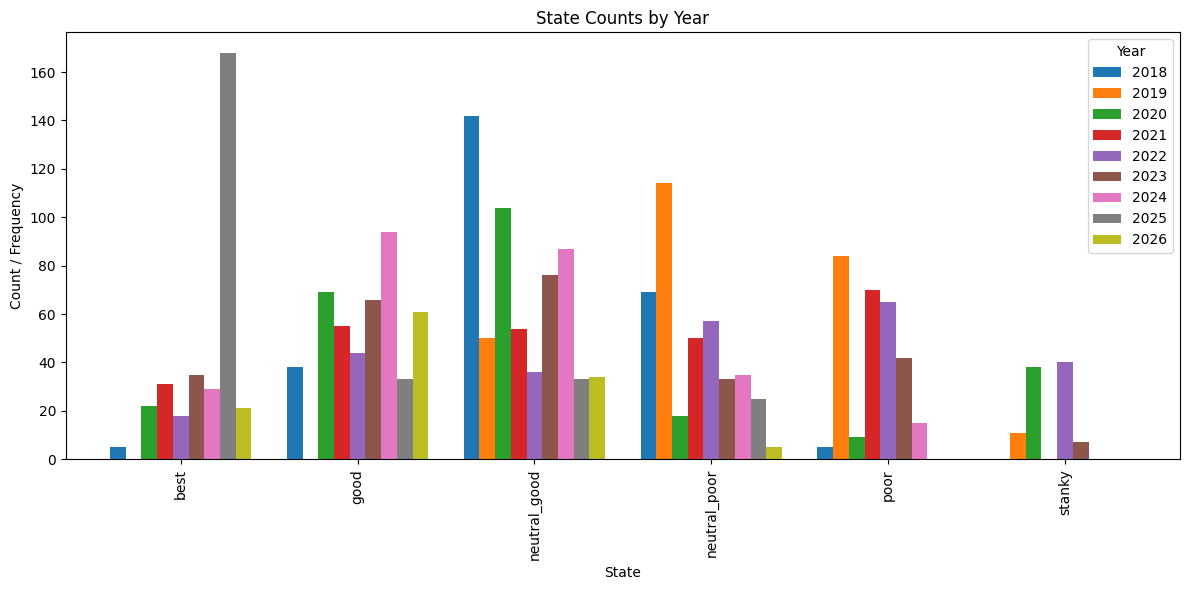

In [572]:
state_year_counts = (
    macro_df.groupby(["states", pd.to_datetime(macro_df.index).year])
    .size()
    .unstack(fill_value=0)
)

ax = state_year_counts.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

ax.set_xlabel("State")
ax.set_ylabel("Count / Frequency")
ax.set_title("State Counts by Year")
ax.legend(title="Year")
plt.tight_layout()
plt.show()


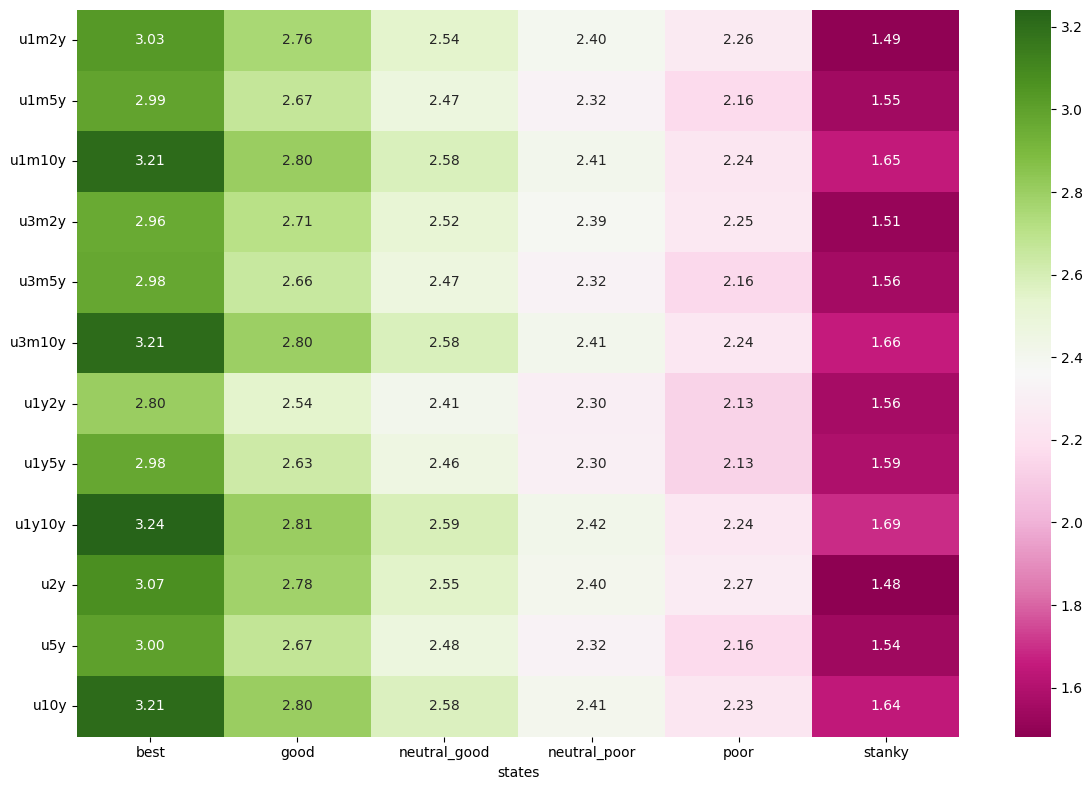

In [573]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(regime_macro_rates.T, annot=True, fmt='.2f', cmap='PiYG') # regime_macro_rates, regime_macro_ivs, regime_macro_rvs
plt.tight_layout()

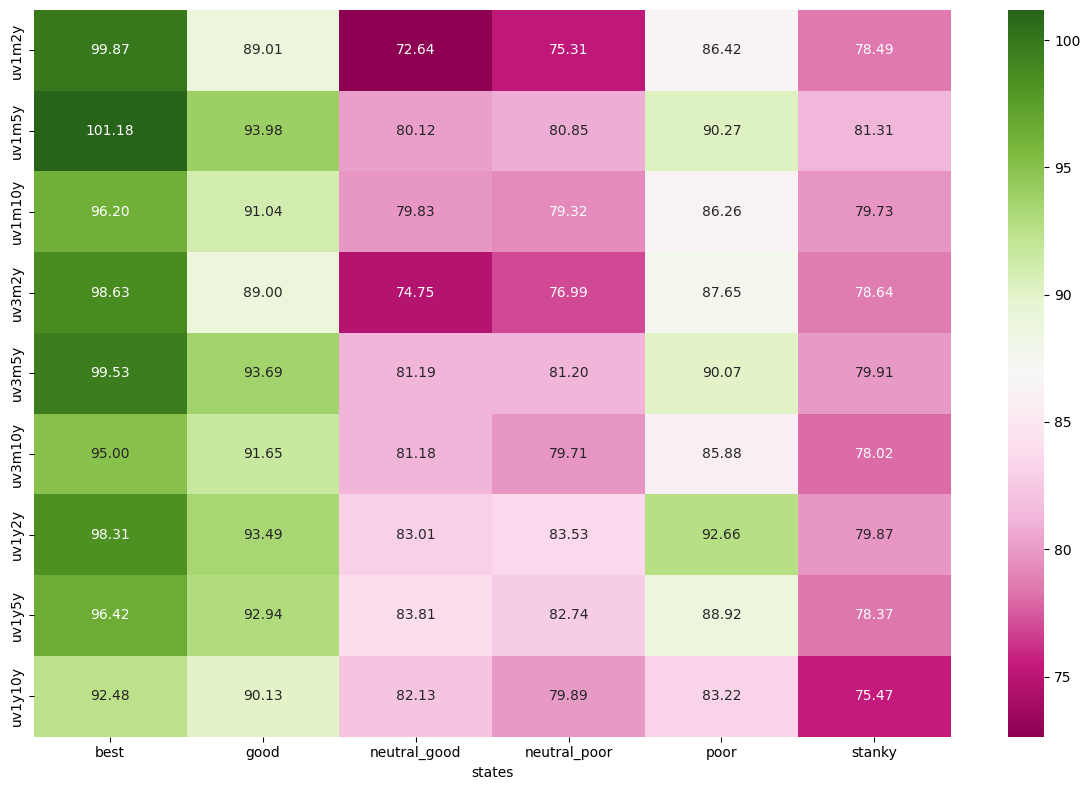

In [574]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(regime_macro_ivs.T, annot=True, fmt='.2f', cmap='PiYG') # regime_macro_rates, regime_macro_ivs, regime_macro_rvs
plt.tight_layout()

# reason for very high iv, which is associated with very volatile, chaotic market periods. Therefore there needs to be high implied vol, but not so high where we're operating in a illiquid, crisis regime.

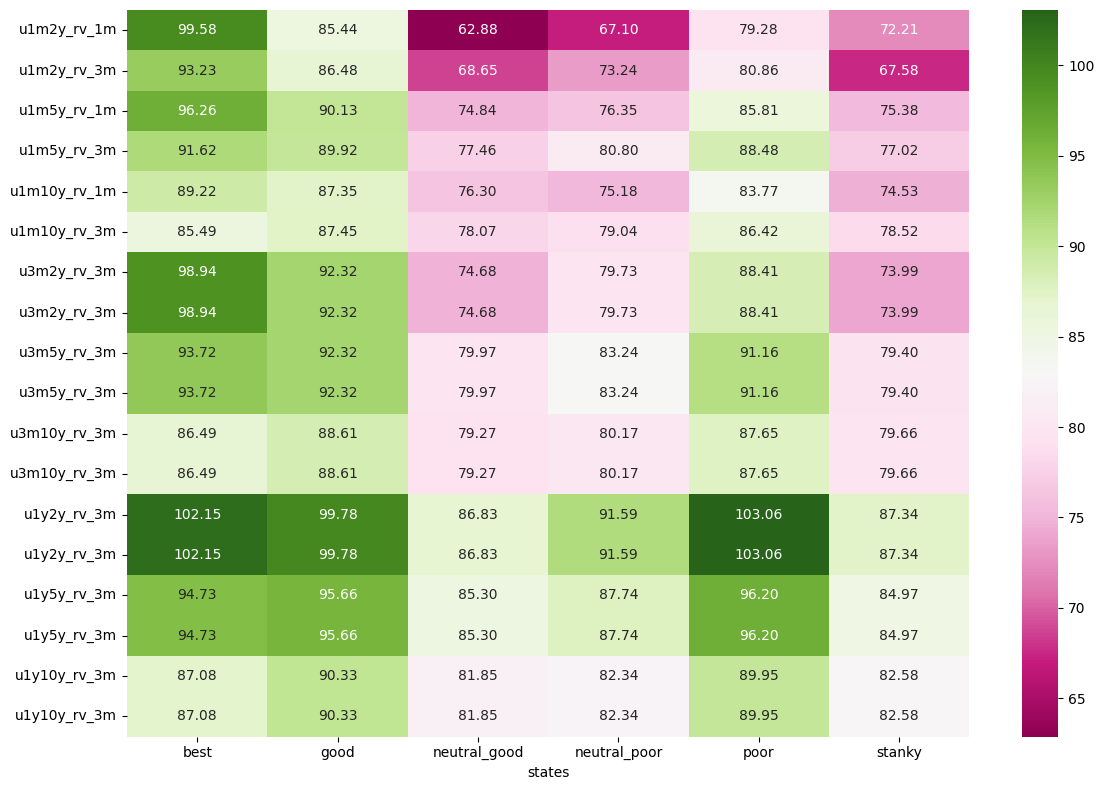

In [575]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(regime_macro_rvs.T, annot=True, fmt='.2f', cmap='PiYG') # regime_macro_rates, regime_macro_ivs, regime_macro_rvs
plt.tight_layout()

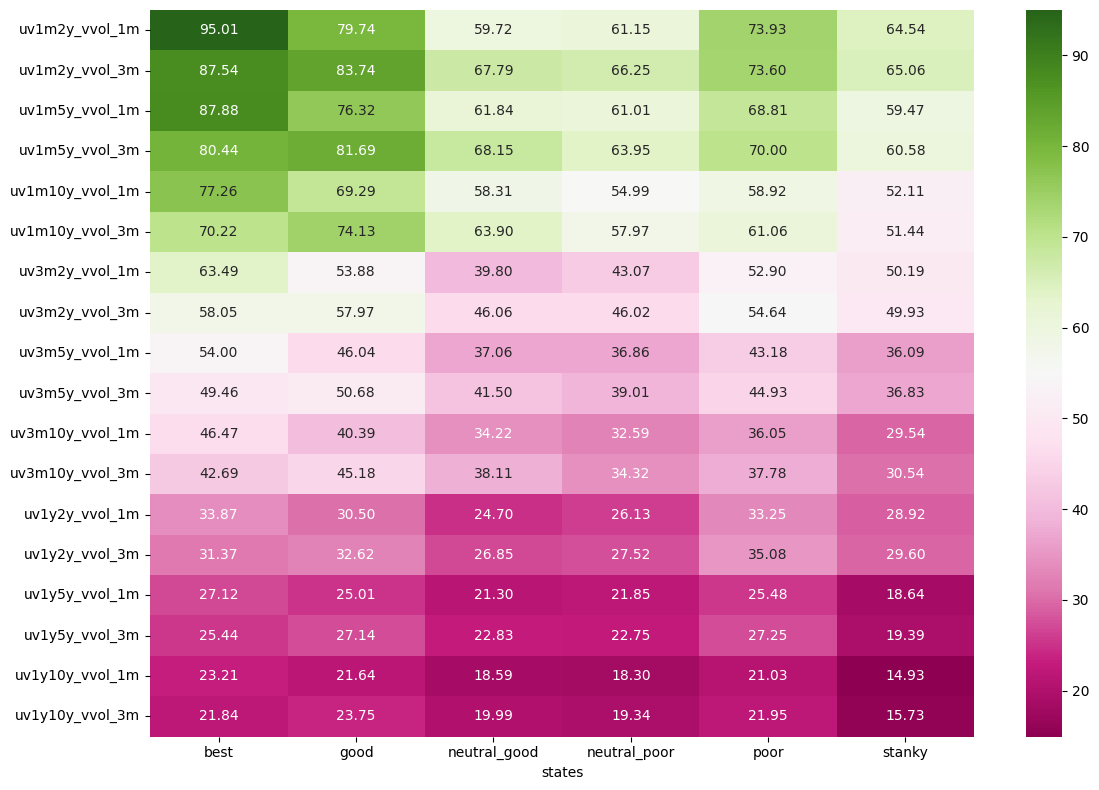

In [576]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(regime_macro_vvol.T, annot=True, fmt='.2f', cmap='PiYG') # regime_macro_rates, regime_macro_ivs, regime_macro_rvs
plt.tight_layout()

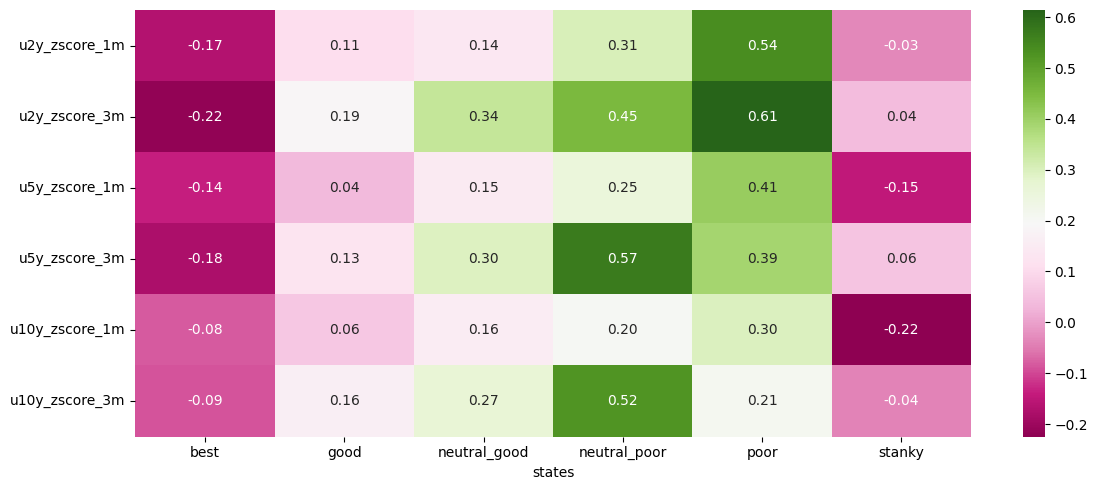

In [577]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(regime_macro_rates_zscore.T, annot=True, fmt='.2f', cmap='PiYG') # regime_macro_rates, regime_macro_ivs, regime_macro_rvs
plt.tight_layout()

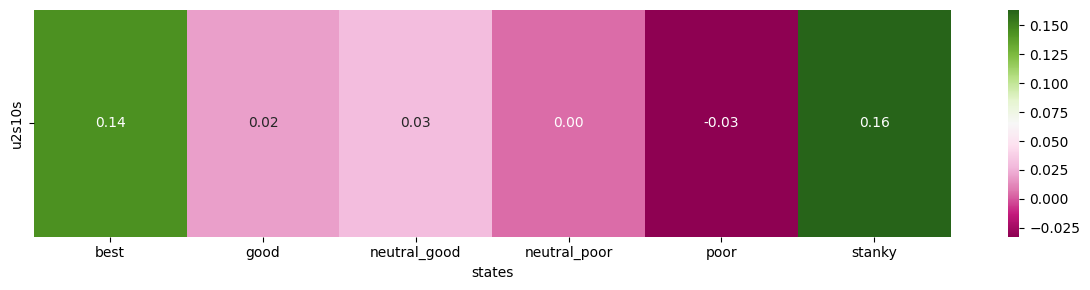

In [578]:
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(regime_macro_u2s10s.T, annot=True, fmt='.2f', cmap='PiYG') # regime_macro_rates, regime_macro_ivs, regime_macro_rvs
plt.tight_layout()

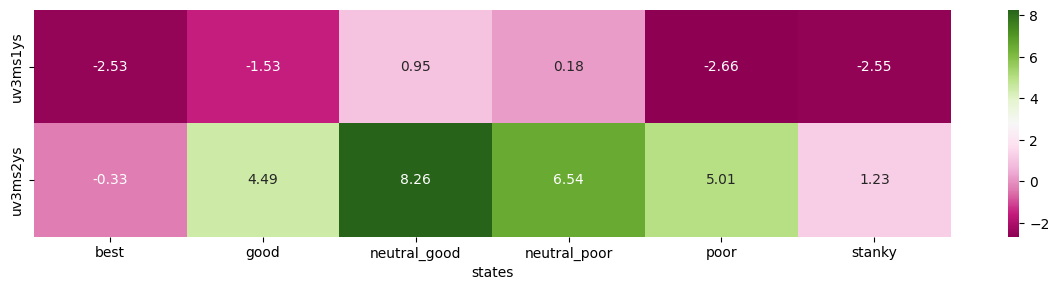

In [579]:
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(regime_macro_vol_curve.T, annot=True, fmt='.2f', cmap='PiYG') # regime_macro_rates, regime_macro_ivs, regime_macro_rvs
plt.tight_layout()

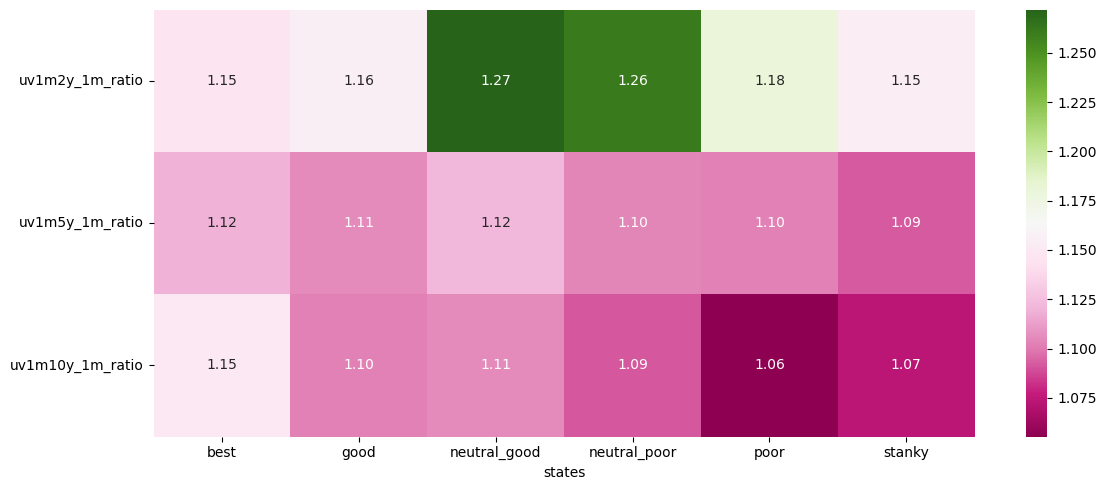

In [580]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(regime_macro_1m_vrp.T, annot=True, fmt='.2f', cmap='PiYG') # regime_macro_rates, regime_macro_ivs, regime_macro_rvs
plt.tight_layout()

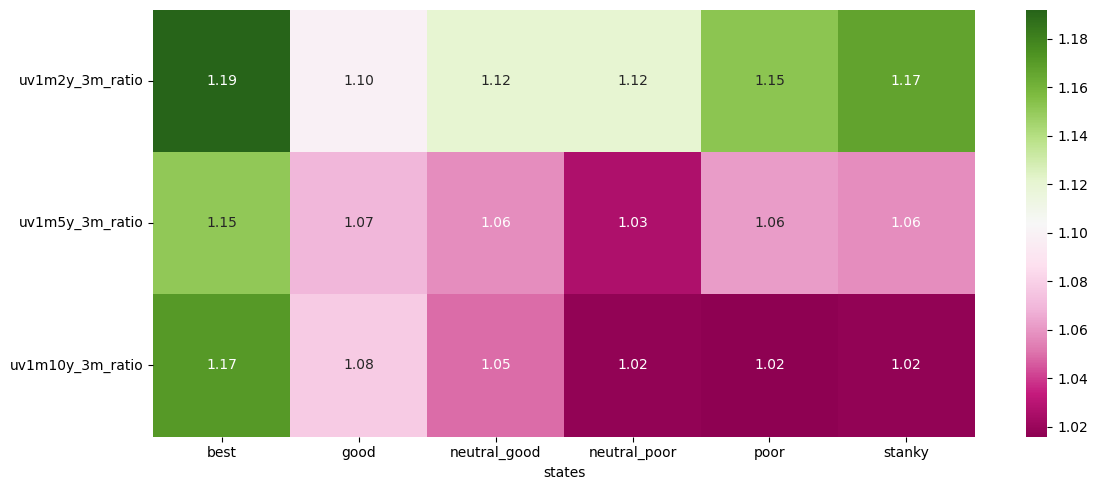

In [581]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(regime_macro_3m_vrp.T, annot=True, fmt='.2f', cmap='PiYG') # regime_macro_rates, regime_macro_ivs, regime_macro_rvs
plt.tight_layout()

## Plot distributions of each variable in best

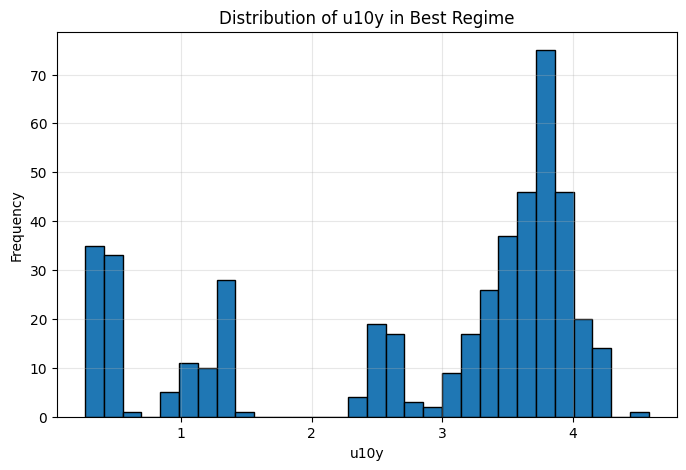

In [582]:
# macro_df[macro_df['states'] == "best"]['u10y'].describe()

plt.figure(figsize=(8, 5))

plt.hist(
    macro_df[macro_df['states'] == "good"]['u10y'],
    bins=30,
    edgecolor="black"
)

plt.xlabel("u10y")
plt.ylabel("Frequency")
plt.title("Distribution of u10y in Best Regime")
plt.grid(alpha=0.3)

plt.show()


## Actually see what variables are statistically significant in explaining the regime level

In [583]:
macro_df

,u10y,u1m10y,u1m2y,u1m5y,u1y10y,u1y2y,u1y5y,u2y,u3m10y,u3m2y,...,u2s10s,uv3ms1ys,uv3ms2ys,uv1m2y_1m_ratio,uv1m2y_3m_ratio,uv1m5y_1m_ratio,uv1m5y_3m_ratio,uv1m10y_1m_ratio,uv1m10y_3m_ratio,states
date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,2.109043,2.117444,1.888239,2.012385,2.176776,2.060211,2.092979,1.859972,2.131971,1.939006,...,0.249071,5.124043,11.011793,1.280600,1.277437,1.155018,1.217851,1.031792,1.163243,neutral_poor
2018-01-03,2.096613,2.104579,1.896437,2.013793,2.161508,2.066818,2.091860,1.868524,2.118936,1.947871,...,0.228090,5.640940,11.114278,1.269932,1.218008,1.143795,1.156833,1.029900,1.099442,neutral_poor
2018-01-04,2.116153,2.124140,1.925990,2.044630,2.180155,2.108327,2.119267,1.894937,2.138918,1.979940,...,0.221216,6.087501,10.879401,1.232716,1.184715,1.109792,1.125788,1.020528,1.075549,neutral_poor
2018-01-05,2.134144,2.142235,1.930974,2.057309,2.199172,2.120300,2.135480,1.899699,2.156892,1.985558,...,0.234445,6.781320,12.013759,1.181785,1.140276,1.071428,1.090160,0.999635,1.038205,neutral_poor
2018-01-08,2.137664,2.146402,1.922024,2.054857,2.204057,2.107778,2.136343,1.890096,2.160419,1.973487,...,0.247567,6.672269,11.829948,1.304782,1.173646,1.169833,1.125394,1.059893,1.070207,neutral_poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-15,4.066975,4.073622,3.931136,3.913887,4.130199,3.925980,3.947929,3.922646,4.086809,3.944910,...,0.144328,8.816689,7.545652,1.181818,1.051648,1.068328,1.022818,1.061621,1.028970,neutral_poor
2026-06-16,4.019579,4.026255,3.910334,3.875533,4.076734,3.883386,3.897584,3.903066,4.037770,3.919446,...,0.116513,9.368685,8.326961,1.118960,1.027230,1.032628,0.993102,1.024522,0.982564,neutral_poor
2026-06-17,4.050631,4.056505,4.030473,3.947987,4.091492,3.975518,3.946366,4.020214,4.067046,4.042099,...,0.030417,8.548204,6.566155,0.976087,1.000791,0.998832,1.010024,1.058842,1.045479,neutral_poor


## Initial Conclusions and Notes

- Regime 0 achieves the most favorable mean PnL across strategies, 

## Random Forest

Can help us identify what macro variables predict high vs. low PnL. Supervised learning approach

In [584]:
from sklearn.ensemble import RandomForestClassifier
import shap

pnl_total = pnl_df.sum(axis=1)

labels = pd.qcut(pnl_total, q=3, labels=['low', 'med', 'high'])

# Step 2: Use macro variables as features
aligned = macro_df.join(labels.rename('regime')).dropna()
X = aligned.drop(columns='regime')
y = aligned['regime']

# Step 3: Train classifier
clf = RandomForestClassifier(n_estimators=500, max_depth=5, random_state=42)
clf.fit(X, y)

# Step 4: Explain with SHAP
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)   # ranks features by importance, per regime

ValueError: could not convert string to float: 'neutral_poor'

In [ ]:
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

pnl_total = pnl_df.sum(axis=1).dropna()

ms_model = MarkovRegression(
    pnl_total, 
    k_regimes=3, 
    trend='c',
    switching_variance=True,
)
res = ms_model.fit()
print(res.summary())

# Smoothed probabilities of being in each regime
smoothed_probs = res.smoothed_marginal_probabilities

c:\Users\s1799275\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\s1799275\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                        Markov Switching Model Results                        
Dep. Variable:                      y   No. Observations:                 2160
Model:               MarkovRegression   Log Likelihood              -19599.903
Date:                Fri, 19 Jun 2026   AIC                          39223.805
Time:                        16:55:21   BIC                          39291.940
Sample:                             0   HQIC                         39248.725
                               - 2160                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        388.7989     24.336     15.976      0.000     341.100     436.498
sigma2      3.971e+05   2.57e+04     15.472      0.0

## Appendix

In [ ]:


scoring_criteria = {"total": 0.5,
                    "mdd": 0.3,
                    "var_95": 0.3,
                    "min": 0.2}

# get mean, std, min, var95 for each metric and rank the most favorable regimes


criteria_list = list(scoring_criteria.keys())

scoring_df = regime_profile_min[criteria_list]
scoring_df_z = (scoring_df - scoring_df.mean()) / scoring_df.std()

criteria_weights = pd.Series(scoring_criteria)
score_df = scoring_df_z * criteria_weights
score_df['composite'] = score_df.sum(axis=1)
score_df = score_df.sort_values('composite', ascending=False)
score_df

,total,mdd,var_95,min,composite
states,,,,,
1,0.280301,0.565272,0.575600,0.397227,1.818399
5,0.052397,-0.002925,0.010286,-0.022913,0.036845
4,0.527279,-0.247268,-0.198724,-0.117134,-0.035847
3,0.335514,-0.070783,-0.198724,-0.117134,-0.051127
0,-0.419566,0.009130,0.010286,-0.022913,-0.423062
2,-0.775924,-0.253425,-0.198724,-0.117134,-1.345207
